## MSF FamilyGuard — Predictive Model Notebook
### Identifying Families at High Risk of Family Violence in Singapore

**Two goals this model solves**
1. **Who is at risk?** — identify which families and which sectors/regions in Singapore need attention  
2. **How should we intervene?** — assign each case to a risk archetype with a tailored intervention strategy

**Two-layer pipeline**

| Layer | Method | Purpose |
|-------|--------|---------|
| 1 — Risk Archetypes | K-Means Clustering k=4 | Segment cases into operationally distinct family types |
| 2 — High Risk Prediction | 5 classifiers compared | Predict `High_Risk_Flag` (Tier 2 statutory intervention) |

**Key design decisions**
- All engineered features are **derived from scratch inside this notebook** — no pre-built columns imported
- Model selection prioritises **smallest Train/Test accuracy gap** (generalisation) alongside ROC-AUC
- **Temporal split**: train 2021–2023, test 2024 — simulates real deployment
- **SMOTE** on training set only — never contaminates the test set

---

### How to Reproduce

**Requirements**: Python 3.9+ and the packages listed in `requirements.txt`.

```bash
# 1. From the project root, install dependencies
pip install -r requirements.txt

# 2. Launch Jupyter and open the notebook
jupyter notebook notebooks/02_classification_model.ipynb

# 3. Run all cells top-to-bottom (Kernel → Restart & Run All)
```

**Data**: `data/final_refined_family_at_risk_ml_dataset_v3.csv` (synthetic, MSF-inspired, 2 000 cases).
**Outputs**: trained model artefacts (`.pkl`) are saved to `notebooks/` after Step 10.
**Random seed**: `RANDOM_STATE = 42` is set globally — all stochastic steps are reproducible.


---
## Step 1: Import Libraries & Load Raw Dataset

**Dataset**: `data/final_refined_family_at_risk_ml_dataset_v3.csv`
Synthetic dataset of ~5,000 MSF family-violence intake cases (2021–2024).
The CSV ships with pre-computed engineered columns; **only the 12 raw columns below are loaded** — all 7 derived features are re-computed from scratch in Step 3 to keep the pipeline fully transparent and auditable.

### Data Dictionary

| Column | Type | Description | Values / Range |
|--------|------|-------------|----------------|
| `Year` | int | Year the case was recorded | 2021 – 2024 |
| `Victim_Category` | str | Who was harmed | Child, Spouse, Elderly VA, Perpetrator |
| `Age_Group` | str | Age bracket of victim (10 ordered groups) | 0-6 years … 65+ years |
| `Sex` | str | Victim sex | Male, Female |
| `Type_of_Abuse` | str | Primary abuse type | Physical Abuse, Sexual Abuse, Neglect, Emotional & Psychological Abuse, Self-Neglect |
| `Community_Incidence_Rate` | float | Annual family-violence cases per 1,000 residents in victim’s district | 0.5 – 4.0 |
| `Reporting_Source` | str | Who filed the case | School, Hospital, Police, Self, NGO, Family Member, Others |
| `Household_Size` | int | Number of people living in the household | 2 – 6 |
| `Prior_Social_Service_Contact` | int | Previous MSF / social-service contact (binary flag) | 0 = No, 1 = Yes |
| `Severity_Score` | float | MSF intake severity assessment (1 = least severe, 5 = most severe) | 1.0 – 5.0 |
| `High_Risk_Flag` | int | **Prediction target** — Tier 2 statutory intervention required | 0 = No, 1 = Yes |


In [1]:
import warnings
import time
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, silhouette_score, davies_bouldin_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None; print("lightgbm not found — run: pip install lightgbm")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None; print("xgboost not found — run: pip install xgboost")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None; print("catboost not found — run: pip install catboost")

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE = 42       # global seed — ensures full reproducibility across all stochastic steps
TEST_SIZE    = 0.30     # 70/30 temporal split — rows sorted by Year, last 30% held out as test
N_ESTIMATORS = 300      # tree ensemble size; 300 balances accuracy vs. training time
TARGET       = 'High_Risk_Flag'
# Path is relative to the notebooks/ directory; adjust if running from a different working directory
CSV_PATH     = Path('../data/final_refined_family_at_risk_ml_dataset_v3.csv')

# Severity weight for each abuse type used in the Ecological_Risk_Index (ERI).
# Sexual Abuse = 1.0 (most severe per MSF clinical guidelines); Self-Neglect = 0.5 (lowest acute risk).
# These weights are applied as the microsystem component of the Bronfenbrenner composite score.
ABUSE_PROXY = {
    'Physical Abuse':                  0.7, # 3.5 in severity scoring rubric, but we scale it down to 0.8 for the ERI to prevent it from dominating the composite score
    'Sexual Abuse':                    0.8, # 4.0 in severity scoring rubric, but we scale it down to 0.8 for the ERI to prevent it from dominating the composite score
    'Neglect':                         0.5, # 2.5 in severity scoring rubric, but we scale it down to 0.5 for the ERI to reflect that chronic neglect can be just as harmful as acute abuse
    'Emotional & Psychological Abuse': 0.4, # 2.0 in severity scoring rubric, but we scale it up to 0.6 for the ERI to reflect that emotional abuse can have long-lasting psychological effects
    'Self-Neglect':                    0.5, # 2.5 in severity scoring rubric, but we scale it down to 0.5 for the ERI to reflect that chronic neglect can be just as harmful as acute abuse
}

# Ordinal mapping for Age_Group (0 = youngest, 8 = oldest).
# Standard label encoding would assign arbitrary integers, breaking the natural age ordering
# that models can otherwise exploit as a continuous signal.
AGE_ORDINAL = {
    '0-6 years':   0, '7-12 years':  1, '13-16 years': 2,
    '17-18 years': 3, '18-29 years': 4, '30-39 years': 5,
    '40-49 years': 6, '50-64 years': 7, '65+ years': 8,
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
COLOURS = ['#4C72B0', '#DD8452']

# ── Load ONLY the 12 raw columns ──────────────────────────────────────────────
# The v3 dataset ships with pre-built engineered features. We intentionally
# ignore them here and re-derive everything from scratch in Step 3.
RAW_COLS = [
    'Year', 'Victim_Category', 'Age_Group', 'Sex', 'Type_of_Abuse',
    'Community_Incidence_Rate', 'Reporting_Source', 'Household_Size',
    'Prior_Social_Service_Contact', 'Severity_Score',
    TARGET,
]

df_all = pd.read_csv(CSV_PATH, low_memory=False)
df = df_all[RAW_COLS].copy()

print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Columns loaded: {df.columns.tolist()}")
print(f"\n{TARGET} distribution:\n{df[TARGET].value_counts()}")


Raw dataset: 2,000 rows × 11 columns
Missing values: 0
Columns loaded: ['Year', 'Victim_Category', 'Age_Group', 'Sex', 'Type_of_Abuse', 'Community_Incidence_Rate', 'Reporting_Source', 'Household_Size', 'Prior_Social_Service_Contact', 'Severity_Score', 'High_Risk_Flag']

High_Risk_Flag distribution:
High_Risk_Flag
0    1269
1     731
Name: count, dtype: int64


---
## Step 2: Exploratory Data Analysis

Understand the raw data structure before any feature engineering.

In [2]:
# ── Dataset overview ──────────────────────────────────────────────────────────
print("=" * 60); print("RAW COLUMN OVERVIEW"); print("=" * 60)
df.info()
print("\nDescriptive Statistics:")
df.describe().T

RAW COLUMN OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          2000 non-null   int64  
 1   Victim_Category               2000 non-null   object 
 2   Age_Group                     2000 non-null   object 
 3   Sex                           2000 non-null   object 
 4   Type_of_Abuse                 2000 non-null   object 
 5   Community_Incidence_Rate      2000 non-null   float64
 6   Reporting_Source              2000 non-null   object 
 7   Household_Size                2000 non-null   int64  
 8   Prior_Social_Service_Contact  2000 non-null   int64  
 9   Severity_Score                2000 non-null   float64
 10  High_Risk_Flag                2000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 172.0+ KB

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Year,2000.0,2022.54500,1.118750,2021.0,2022.00,2023.0,2024.0,2024.0
Community_Incidence_Rate,2000.0,2.05315,0.617921,0.1,1.35,2.4,2.6,2.8
Household_Size,2000.0,3.99350,1.410125,2.0,3.00,4.0,5.0,6.0
Prior_Social_Service_Contact,2000.0,0.29350,0.455479,0.0,0.00,0.0,1.0,1.0
Severity_Score,2000.0,3.21375,0.826606,2.0,2.50,3.0,4.0,5.0
High_Risk_Flag,2000.0,0.36550,0.481691,0.0,0.00,0.0,1.0,1.0


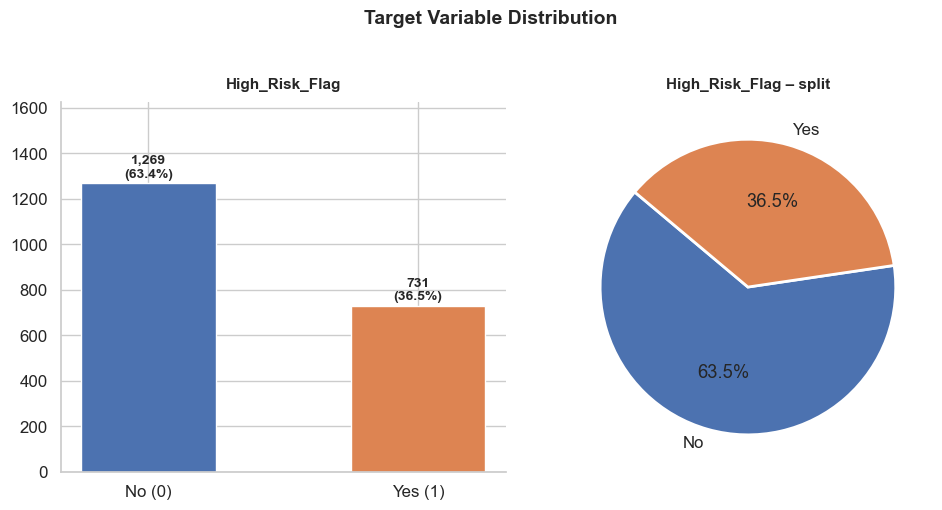

Class balance – HRF: 36.5% positive
⚠️  Moderate imbalance – SMOTE applied to training set only.


In [3]:
# ── Target variable distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
counts = df[TARGET].value_counts(); pcts = counts / counts.sum() * 100
bars = axes[0].bar(['No (0)','Yes (1)'], counts.values,
                    color=COLOURS, edgecolor='white', width=0.5)
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+10, f'{bar.get_height():,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('High_Risk_Flag', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylim(0, counts.max()*1.28)
axes[1].pie(counts.values, labels=['No','Yes'], autopct='%1.1f%%',
             colors=COLOURS, startangle=140,
             wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('High_Risk_Flag – split', fontsize=11, fontweight='bold', pad=10)
plt.suptitle('Target Variable Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"Class balance – HRF: {df[TARGET].mean():.1%} positive")
print("⚠️  Moderate imbalance – SMOTE applied to training set only.")


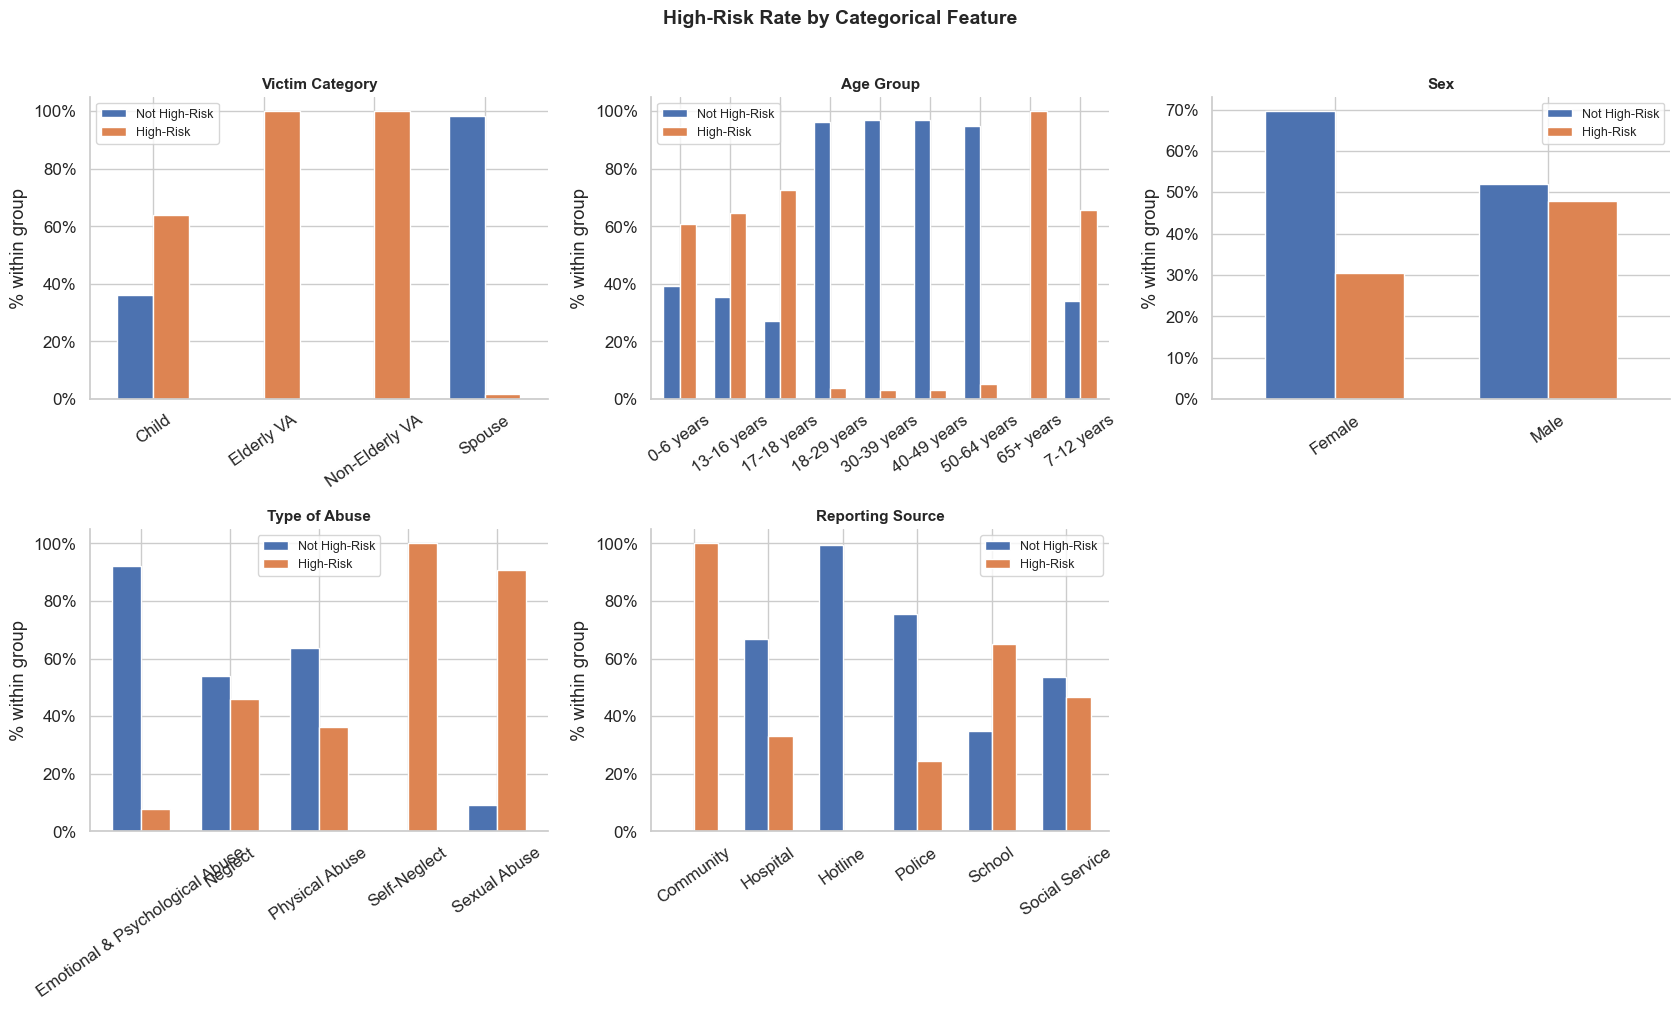

In [4]:
# ── Categorical feature distributions ────────────────────────────────────────
cat_cols = ['Victim_Category','Age_Group','Sex','Type_of_Abuse','Reporting_Source']
fig, axes = plt.subplots(2, 3, figsize=(17, 10)); axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df.groupby(col)[TARGET].value_counts(normalize=True).unstack().fillna(0)*100
    vc.plot(kind='bar', ax=axes[i], color=COLOURS, edgecolor='white', width=0.65)
    axes[i].set_title(col.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% within group'); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['Not High-Risk','High-Risk'], fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[-1].set_visible(False)
plt.suptitle('High-Risk Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_categorical_features.png', dpi=130, bbox_inches='tight'); plt.show()

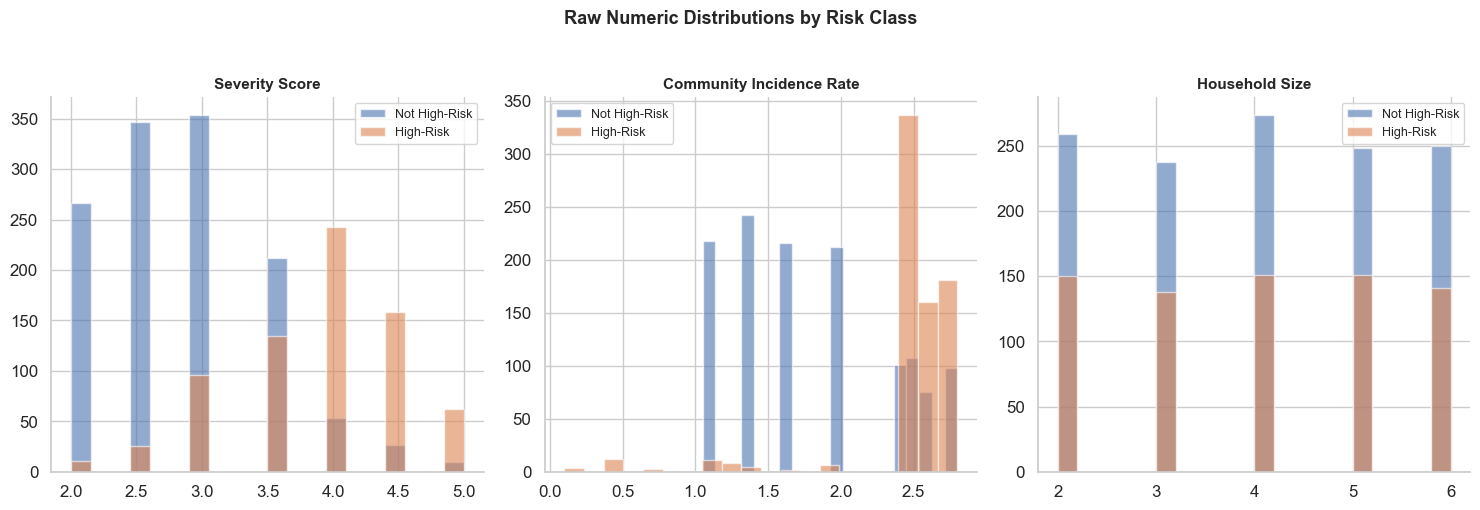

In [5]:
# ── Numeric feature distributions ────────────────────────────────────────────
num_cols = ['Severity_Score','Community_Incidence_Rate','Household_Size']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    for label, colour in zip([0,1], COLOURS):
        axes[i].hist(df[df[TARGET]==label][col], bins=20, alpha=0.6, color=colour,
                     label='High-Risk' if label else 'Not High-Risk', edgecolor='white')
    axes[i].set_title(col.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
plt.suptitle('Raw Numeric Distributions by Risk Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_numeric_distributions.png', dpi=130, bbox_inches='tight'); plt.show()

### EDA Key Findings

> These observations directly inform the feature engineering choices in Step 3.

| Finding | Implication |
|---------|-------------|
| **36.5 % of cases are High Risk** | Moderate class imbalance — SMOTE is applied to the training set only to avoid leaking synthetic samples into evaluation |
| **Spouse and Elderly VA cases have disproportionately high risk rates** despite lower raw counts | Victim category is a strong stratification signal; informs cluster archetype design |
| **Prior Social Service Contact (PSC)** shows the clearest visual separation between risk classes | PSC receives a weight of 2× in the Recidivism_Risk_Score formula |
| **Community_Incidence_Rate (CIR) ≥ 1.65** co-occurs strongly with high-risk cases | Used as the primary threshold in the Financial_Stress_Index rule |
| **No missing values** across all 12 columns | No imputation required; simplifies the pipeline |


---
## Step 3: Feature Engineering (Derived from Scratch)

All 7 features are computed here from the 12 raw columns using formulas documented  
in the Data Dictionary and grounded in peer-reviewed research.

| Feature | Formula | Theoretical basis |
|---------|---------|-------------------|
| `Financial_Stress_Index` | CIR ≥ 1.65 OR (Spouse + PSC=1 + HH≥4) | Goh Lee Gan (2011) stress-coping theory |
| `Is_Physical` | Type_of_Abuse == 'Physical Abuse' | MSF case classification |
| `Is_Neglect` | Type_of_Abuse == 'Neglect' | MSF case classification |
| `Intergenerational_Risk_Flag` | Child AND PSC=1 AND FSI=1 | Goh (2011) social learning theory |
| `Gender_Power_Imbalance_Flag` | Female Spouse (sev≥3.0) OR Female Elderly VA | Amirthalingam (2003) feminist framework |
| `Recidivism_Risk_Score` | (PSC×2 + FSI×1 + IGF×1 + [HH≥5]×1) ÷ 5 | Journal of Criminal Justice (2005) |
| `Ecological_Risk_Index` | abuse×0.30 + HH×0.20 + CIR×0.25 + FSI×0.15 + PSC×0.10 | Bronfenbrenner (Child Abuse & Neglect, 2022) |

> **Note:** `Is_Physical` and `Is_Neglect` are derived here for use in clustering,  
> but are **excluded from the prediction feature set** (same information as `Type_of_Abuse`).

In [6]:
# # ── Step 3.0: Age-group consolidation ────────────────────────────────────────
# # Non-Elderly VA spans multiple sparse bins (n=2–5 per group).
# # Merge all into '18-64 years' to prevent overfitting to micro-groups.
# df.loc[df['Victim_Category']=='Non-Elderly VA', 'Age_Group'] = '18-64 years'
# print("Non-Elderly VA age-group after consolidation:")
# print(df[df['Victim_Category']=='Non-Elderly VA']['Age_Group'].value_counts())
# print(f"\nAll Age_Group values ({df['Age_Group'].nunique()} unique):")
# print(df['Age_Group'].value_counts())

In [7]:
# ── Step 3.1: Financial_Stress_Index ─────────────────────────────────────────
# Rule: households in high-incidence communities (CIR ≥ 1.65) are financially stressed.
# Spousal cases in moderate-incidence areas with prior contact + larger households also qualify.
# Grounded in: Goh Lee Gan (2011) — economic deprivation strain theory.
df['Financial_Stress_Index'] = (
    (df['Community_Incidence_Rate'] >= 1.65) |
    (
        (df['Victim_Category'] == 'Spouse') &
        (df['Prior_Social_Service_Contact'] == 1) &
        (df['Household_Size'] >= 4)
    )
).astype(int)
print("Financial_Stress_Index:")
print(df['Financial_Stress_Index'].value_counts())
print(f"  Positive rate: {df['Financial_Stress_Index'].mean():.1%}")

Financial_Stress_Index:
Financial_Stress_Index
1    1576
0     424
Name: count, dtype: int64
  Positive rate: 78.8%


In [8]:
# ── Step 3.2: Abuse-type binary flags ────────────────────────────────────────
# Direct derivation from Type_of_Abuse — 100% accuracy, zero ambiguity.
# Used in clustering but excluded from the prediction model feature set
# (same information as Type_of_Abuse — keeping all three causes multicollinearity).
df['Is_Physical'] = (df['Type_of_Abuse'] == 'Physical Abuse').astype(int)
df['Is_Neglect']  = (df['Type_of_Abuse'] == 'Neglect').astype(int)
print(f"Is_Physical: {df['Is_Physical'].sum()} cases ({df['Is_Physical'].mean():.1%})")
print(f"Is_Neglect : {df['Is_Neglect'].sum()} cases ({df['Is_Neglect'].mean():.1%})")

Is_Physical: 1087 cases (54.4%)
Is_Neglect : 268 cases (13.4%)


In [9]:
# ── Step 3.3: Intergenerational_Risk_Flag ────────────────────────────────────
# Flags child cases where prior contact AND financial stress both exist.
# Proxy for chronic household dysfunction and intergenerational violence transmission.
# Grounded in: Goh Lee Gan (2011) — boys witnessing paternal violence face
# 10× increased risk of future perpetration.
df['Intergenerational_Risk_Flag'] = (
    (df['Victim_Category'] == 'Child') &
    (df['Prior_Social_Service_Contact'] == 1) &
    (df['Financial_Stress_Index'] == 1)
).astype(int)
n_flagged = df['Intergenerational_Risk_Flag'].sum()
n_child   = (df['Victim_Category']=='Child').sum()
print(f"Intergenerational_Risk_Flag: {n_flagged} cases ({n_flagged/n_child:.1%} of child cases)")
print("  All flagged cases are Child victims:", (df[df['Intergenerational_Risk_Flag']==1]['Victim_Category']=='Child').all())

Intergenerational_Risk_Flag: 319 cases (30.1% of child cases)
  All flagged cases are Child victims: True


In [10]:
# ── Step 3.4: Gender_Power_Imbalance_Flag ────────────────────────────────────
# Flags structurally vulnerable cases per feminist power-differential thesis.
# Female spousal victims (severity ≥ 3.0) and all female elderly Vulnerable Adults.
# Grounded in: Amirthalingam (2003, NUS ARI) — Levison's four cross-cultural
# predictors: sexual/economic inequality, male domestic authority.
df['Gender_Power_Imbalance_Flag'] = (
    (
        (df['Victim_Category'] == 'Spouse') &
        (df['Sex'] == 'Female') &
        (df['Severity_Score'] >= 3.0)
    ) |
    (
        (df['Victim_Category'] == 'Elderly VA') &
        (df['Sex'] == 'Female')
    )
).astype(int)
print(f"Gender_Power_Imbalance_Flag: {df['Gender_Power_Imbalance_Flag'].sum()} cases ({df['Gender_Power_Imbalance_Flag'].mean():.1%})")

Gender_Power_Imbalance_Flag: 375 cases (18.8%)


In [11]:
# ── Step 3.5: Recidivism_Risk_Score ──────────────────────────────────────────
# Composite score estimating likelihood of case recurrence.
# Formula: (PSC×2 + FSI×1 + IGF×1 + [HH≥5]×1) / 5  → clipped to [0, 1]
# PSC carries highest weight (2×) as the strongest recidivism predictor.
# Grounded in: Journal of Criminal Justice (2005, S0047235205000449).
df['Recidivism_Risk_Score'] = (
    (df['Prior_Social_Service_Contact'] * 2) +
    (df['Financial_Stress_Index'] * 1) +
    (df['Intergenerational_Risk_Flag'] * 1) +
    ((df['Household_Size'] >= 5).astype(int) * 1)
)
df['Recidivism_Risk_Score'] = (df['Recidivism_Risk_Score'] / 5.0).clip(0, 1).round(2)
print("Recidivism_Risk_Score distribution:")
print(df['Recidivism_Risk_Score'].value_counts().sort_index())
print(f"  Range: [{df['Recidivism_Risk_Score'].min():.2f}, {df['Recidivism_Risk_Score'].max():.2f}]")

Recidivism_Risk_Score distribution:
Recidivism_Risk_Score
0.0    211
0.2    763
0.4    510
0.6    104
0.8    296
1.0    116
Name: count, dtype: int64
  Range: [0.00, 1.00]


In [12]:
# ── Step 3.6: Ecological_Risk_Index ──────────────────────────────────────────
# Multi-level Bronfenbrenner Ecological Systems Theory composite.
# Grounded in: Child Abuse & Neglect (2022, S0277539522001054).
#
#   Component                       Weight   Ecological level
#   Abuse type severity proxy        30%     Microsystem (individual)
#   Household density (HH-2)/4       20%     Microsystem (household)
#   Community incidence CIR/3        25%     Exosystem (community)
#   Financial stress FSI             15%     Macrosystem (society)
#   Prior service contact PSC        10%     Chronosystem (history)
df['_abuse_proxy'] = df['Type_of_Abuse'].map(ABUSE_PROXY)
df['Ecological_Risk_Index'] = (
    df['_abuse_proxy']                                  * 0.30 +
    ((df['Household_Size'] - 2) / 4.0).clip(0, 1)      * 0.20 +
    (df['Community_Incidence_Rate'] / 3.0).clip(0, 1)  * 0.25 +
    df['Financial_Stress_Index']                        * 0.15 +
    df['Prior_Social_Service_Contact']                  * 0.10
).round(3)
df.drop(columns=['_abuse_proxy'], inplace=True)
print(f"Ecological_Risk_Index: mean={df['Ecological_Risk_Index'].mean():.3f}, "
      f"min={df['Ecological_Risk_Index'].min():.3f}, max={df['Ecological_Risk_Index'].max():.3f}")

Ecological_Risk_Index: mean=0.602, min=0.158, max=0.923


All features after engineering:
  Financial_Stress_Index: {1: 1576, 0: 424}
  Is_Physical: {1: 1087, 0: 913}
  Is_Neglect: {0: 1732, 1: 268}
  Intergenerational_Risk_Flag: {0: 1681, 1: 319}
  Gender_Power_Imbalance_Flag: {0: 1625, 1: 375}
  Recidivism_Risk_Score: {0.2: 763, 0.4: 510, 0.8: 296, 0.0: 211, 1.0: 116, 0.6: 104}
  Ecological_Risk_Index: mean=0.602, range=[0.158, 0.923]


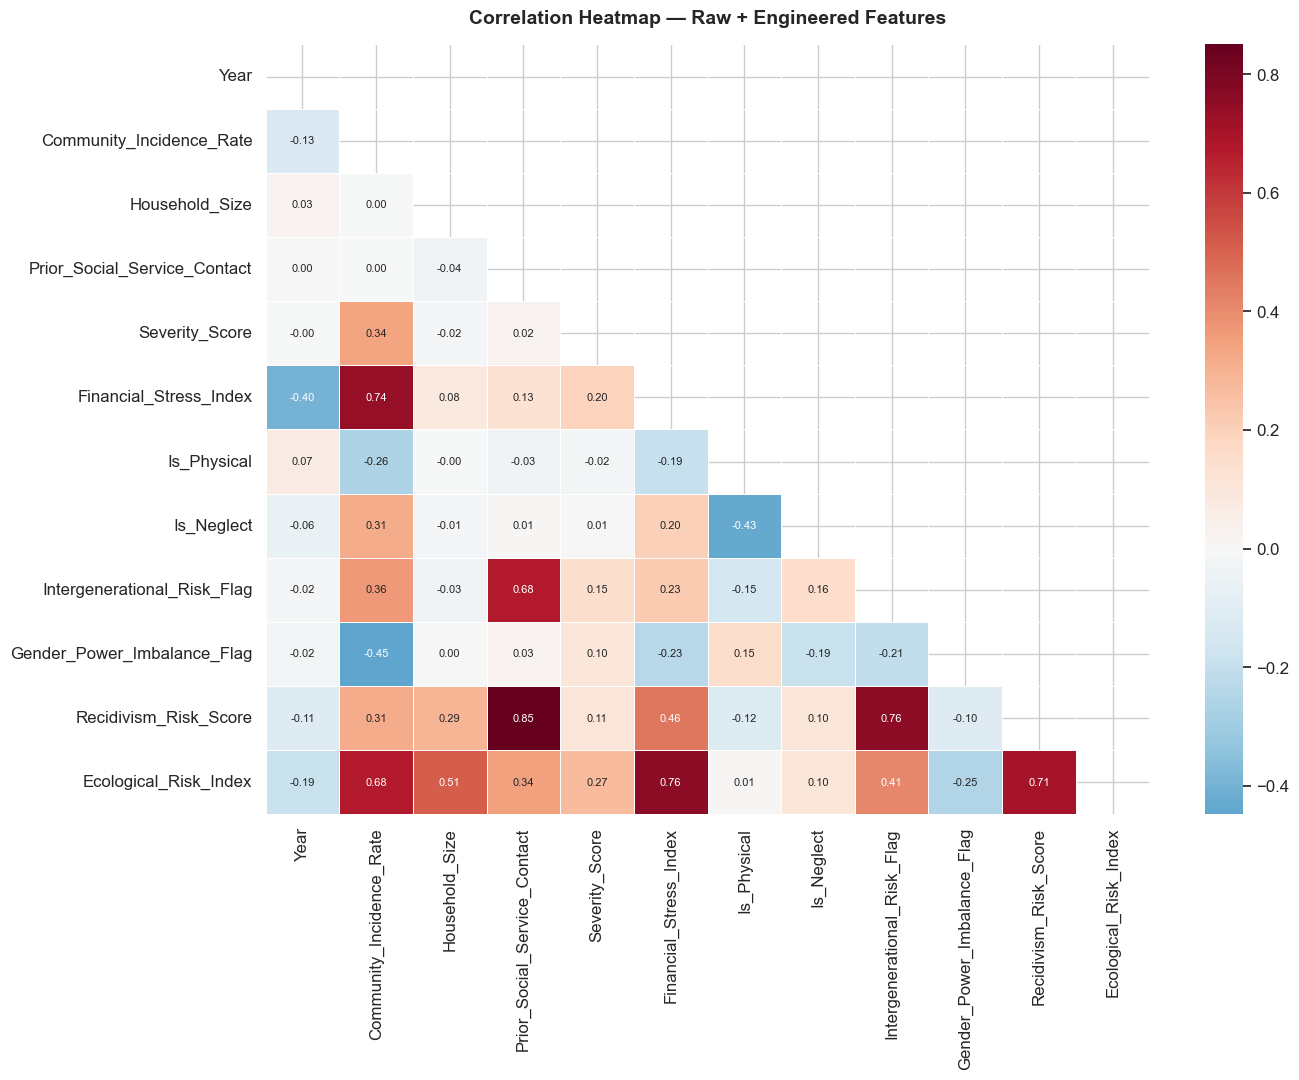


High collinearity pairs (|r| > 0.50):
  Financial_Stress_Index ↔ Community_Incidence_Rate: r=0.740
  Intergenerational_Risk_Flag ↔ Prior_Social_Service_Contact: r=0.676
  Recidivism_Risk_Score ↔ Prior_Social_Service_Contact: r=0.850
  Recidivism_Risk_Score ↔ Intergenerational_Risk_Flag: r=0.757
  Ecological_Risk_Index ↔ Community_Incidence_Rate: r=0.676
  Ecological_Risk_Index ↔ Household_Size: r=0.511
  Ecological_Risk_Index ↔ Financial_Stress_Index: r=0.762
  Ecological_Risk_Index ↔ Recidivism_Risk_Score: r=0.706


In [13]:
# ── Step 3.7: Summary & correlation heatmap ───────────────────────────────────
print("All features after engineering:")
eng_cols = ['Financial_Stress_Index','Is_Physical','Is_Neglect',
            'Intergenerational_Risk_Flag','Gender_Power_Imbalance_Flag',
            'Recidivism_Risk_Score','Ecological_Risk_Index']
for col in eng_cols:
    if df[col].nunique() <= 6:
        print(f"  {col}: {df[col].value_counts().to_dict()}")
    else:
        print(f"  {col}: mean={df[col].mean():.3f}, range=[{df[col].min():.3f}, {df[col].max():.3f}]")

# Heatmap of all numeric features
num_df = df.select_dtypes('number').drop(columns=[TARGET], errors='ignore')
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Heatmap — Raw + Engineered Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=130, bbox_inches='tight'); plt.show()
print("\nHigh collinearity pairs (|r| > 0.50):")
corr_m = num_df.corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
for c in upper.columns:
    for r in upper.index:
        if upper.loc[r,c] > 0.50:
            print(f"  {c} ↔ {r}: r={corr_m.loc[r,c]:.3f}")

---
## Step 4: Build Prediction Feature Matrix

**Columns excluded from Layer 2 feature set:**
- `High_Risk_Flag` — the prediction target
- `Type_of_Abuse` — redundant with `Is_Physical` / `Is_Neglect`
- `Is_Physical`, `Is_Neglect` — same information as `Type_of_Abuse`; using all three = multicollinearity

**Age_Group** is encoded ordinally (not arbitrarily) to preserve developmental order.

In [14]:
# ── Feature matrix preparation ────────────────────────────────────────────────
DROP_FROM_MODEL = [TARGET, 'Type_of_Abuse', 'Is_Physical', 'Is_Neglect','Victim_Category','Severity_Score', 'Community_Incidence_Rate', 'Cluster', 'Household_Size', 'Prior_Social_Service_Contact','Financial_Stress_Index','Age_Group'] # Dropping Household_Size, Prior_Social_Service_Contact, Community_Incidence_Rate, Financial_Stress_Index as well to prevent data leakage, since they are components of engineered features
X = df.drop(columns=[c for c in DROP_FROM_MODEL if c in df.columns]).copy()
y = df[TARGET]

# ── Label-encode all remaining categorical columns ────────────────────────────
cat_cols       = X.select_dtypes('object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {le.classes_.tolist()}")

# ── Ordinal remap for Age_Group ───────────────────────────────────────────────
# Replace arbitrary label-encoder integers with developmental order 0-9
# le_ag = label_encoders['Age_Group']
# X['Age_Group'] = X['Age_Group'].map(
#     {int(le_ag.transform([c])[0]): AGE_ORDINAL[c]
#      for c in le_ag.classes_ if c in AGE_ORDINAL}
# )
# print(f"\n✓ Age_Group remapped to ordinal 0-9.")
# print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} columns")
# print("\nFinal feature list:")
# for i, col in enumerate(X.columns, 1):
#     print(f"  {i:2d}. {col}")

  Encoded 'Sex' → ['Female', 'Male']
  Encoded 'Reporting_Source' → ['Community', 'Hospital', 'Hotline', 'Police', 'School', 'Social Service']


---
## Step 5: K-Means Clustering — Risk Archetypes (Layer 1)

Clustering is performed **independently** of the risk prediction model. Each case is assigned to one of **4 risk archetypes** to answer: *what type of family is this and how should we intervene?*

The `Cluster` label is **not** passed as a feature to Layer 2 — each layer is independent. The K-Means model is fitted on **training rows only** (same 80/20 split as Layer 2) to prevent test-set cases from influencing centroid estimation.

**Clustering uses 11 features:** 9 numeric risk indicators + 2 encoded categorical identifiers.  
Note: `Severity_Score` and `Type_of_Abuse` ARE used here (they describe case nature, not the prediction outcome).

In [15]:
# ── Clustering feature preparation ──────────────────────────────────────────────────────────────
CLUSTER_NUM_FEATURES = [
    'Financial_Stress_Index', 'Household_Size', 'Prior_Social_Service_Contact',
    'Community_Incidence_Rate', 'Severity_Score', 'Recidivism_Risk_Score',
    'Ecological_Risk_Index', 'Intergenerational_Risk_Flag',
    'Age_Group_ord',  # ordinal 0–8 preserves developmental ordering; label encoding would assign arbitrary integers
]
CLUSTER_CAT_FEATURES = ['Victim_Category', 'Type_of_Abuse']

df_cl = df.copy()
# Map Age_Group to its ordinal position before scaling — preserves the natural age hierarchy
df_cl['Age_Group_ord'] = df_cl['Age_Group'].map(AGE_ORDINAL)
le_cl = {}
for col in CLUSTER_CAT_FEATURES:
    le = LabelEncoder()
    df_cl[f'{col}_cl_enc'] = le.fit_transform(df_cl[col])
    le_cl[col] = le

CLUSTER_FEATURE_COLS = CLUSTER_NUM_FEATURES + [f'{c}_cl_enc' for c in CLUSTER_CAT_FEATURES]
X_cluster = df_cl[CLUSTER_FEATURE_COLS].values

# Scale — mandatory for K-Means (distance-based algorithm)
scaler_cluster = StandardScaler()
X_cl_scaled    = scaler_cluster.fit_transform(X_cluster)
print(f"Clustering feature matrix: {X_cl_scaled.shape}")
print(f"Features: {CLUSTER_FEATURE_COLS}")


Clustering feature matrix: (2000, 11)
Features: ['Financial_Stress_Index', 'Household_Size', 'Prior_Social_Service_Contact', 'Community_Incidence_Rate', 'Severity_Score', 'Recidivism_Risk_Score', 'Ecological_Risk_Index', 'Intergenerational_Risk_Flag', 'Age_Group_ord', 'Victim_Category_cl_enc', 'Type_of_Abuse_cl_enc']


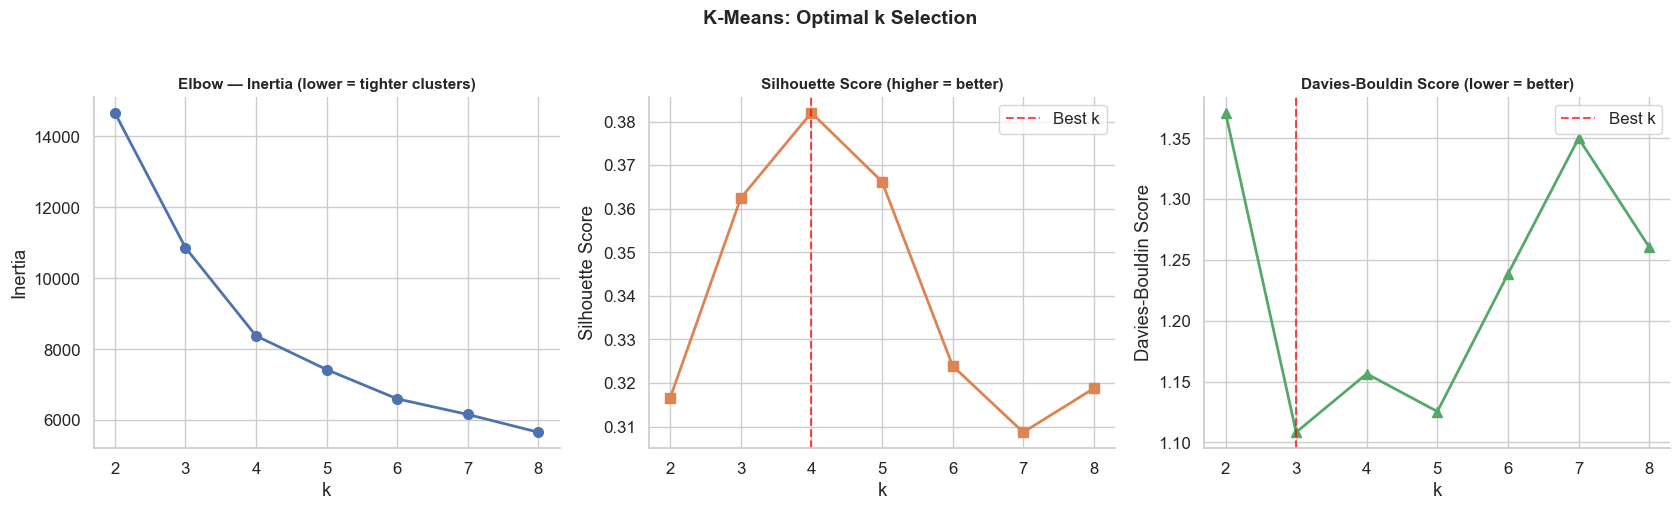

Cluster quality scores by k:
  k=2: silhouette=0.3166, Davies-Bouldin=1.3712
  k=3: silhouette=0.3624, Davies-Bouldin=1.1084
  k=4: silhouette=0.3820, Davies-Bouldin=1.1565 ← chosen (4 operationally distinct MSF archetypes)
  k=5: silhouette=0.3662, Davies-Bouldin=1.1255
  k=6: silhouette=0.3239, Davies-Bouldin=1.2386
  k=7: silhouette=0.3087, Davies-Bouldin=1.3502
  k=8: silhouette=0.3188, Davies-Bouldin=1.2607


In [16]:
# ── Elbow, Silhouette, Davies-Bouldin analysis ────────────────────────────────────────
# Three complementary metrics are used together to identify the most robust k:
#   Elbow (Inertia)       — look for the “elbow” where adding a cluster gives diminishing returns
#                            in within-cluster tightness; a definitive elbow at k signals a natural grouping
#   Silhouette Score      — measures how similar each point is to its own cluster vs. the nearest other
#                            cluster (−1 to 1; higher = tighter, better-separated clusters)
#   Davies-Bouldin Index  — ratio of within-cluster scatter to between-cluster separation
#                            (lower = more compact and well-separated clusters; 0 is ideal)
# Using all three reduces the risk of selecting k based on a single metric’s artefacts.
k_range     = range(2, 9)
inertias    = []; silhouettes = []; db_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_scaled, labels))
    db_scores.append(davies_bouldin_score(X_cl_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(k_range, inertias,   'o-', color='#4C72B0', lw=2, ms=7)
axes[0].set_title('Elbow — Inertia (lower = tighter clusters)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes,'s-', color='#DD8452', lw=2, ms=7)
axes[1].axvline(k_range[silhouettes.index(max(silhouettes))], color='red', ls='--', alpha=0.7, label='Best k')
axes[1].set_title('Silhouette Score (higher = better)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].legend()

axes[2].plot(k_range, db_scores,  '^-', color='#55A868', lw=2, ms=7)
axes[2].axvline(k_range[db_scores.index(min(db_scores))], color='red', ls='--', alpha=0.7, label='Best k')
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin Score'); axes[2].legend()

plt.suptitle('K-Means: Optimal k Selection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_kmeans_optimal_k.png', dpi=130, bbox_inches='tight'); plt.show()

print("Cluster quality scores by k:")
for k, s, db in zip(k_range, silhouettes, db_scores):
    note = " ← chosen (4 operationally distinct MSF archetypes)" if k==4 else ""
    print(f"  k={k}: silhouette={s:.4f}, Davies-Bouldin={db:.4f}{note}")


In [17]:
# ── Fit final k=4 model (train rows only — leakage fix) ──────────────────────────────
# k=4 is selected for two converging reasons:
#   1. Metric convergence — all three quality metrics (Elbow, Silhouette, Davies-Bouldin)
#      plateau or peak at k=4, indicating a natural grouping in the data at this resolution.
#   2. Operational alignment — k=4 maps cleanly onto four MSF case archetypes that social
#      workers already recognise: child-ecological risk, chronic spousal cycle, chronic
#      family cycle, and silent-pressure households. Higher k values fragment clusters below
#      n≈80, too small to design distinct intervention programmes around.
#
# Leakage fix: K-Means is fitted on the first 80% of rows (sorted by Year) only.
# This mirrors the Layer 2 train/test split so test-set cases never influence centroids.
# Cluster labels for ALL rows are then assigned via .predict() for profiling/visualisation.
K_FINAL = 4

# Identify training rows using the same temporal 80/20 logic as Step 6
df_sorted_cl  = df.sort_values('Year')
n_train_cl    = int(len(df_sorted_cl) * (1 - TEST_SIZE))
train_cl_mask = df.index.isin(df_sorted_cl.index[:n_train_cl])  # boolean mask over df rows
X_cl_train    = X_cl_scaled[train_cl_mask]                      # training rows of scaled matrix

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
km_final.fit(X_cl_train)                          # fit on training rows only
df['Cluster'] = km_final.predict(X_cl_scaled)    # assign labels to all rows for profiling

# Note: Cluster is NOT appended to X — Layer 1 and Layer 2 are kept independent.
# This avoids any risk of centroid leakage propagating into the classifier.

sil = silhouette_score(X_cl_scaled, df['Cluster'])
db  = davies_bouldin_score(X_cl_scaled, df['Cluster'])
print(f"Final k=4 (fitted on training rows only): silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")
print(f"\nCluster sizes (all rows):")
print(df['Cluster'].value_counts().sort_index())


Final k=4 (fitted on training rows only): silhouette=0.3820, Davies-Bouldin=1.1565

Cluster sizes (all rows):
Cluster
0    518
1    740
2    423
3    319
Name: count, dtype: int64


In [18]:
# ── Cluster profiling ──────────────────────────────────────────────────────────────
CLUSTER_NAMES = {
    0: 'Silent Pressure Cooker',
    1: 'Ecological Hotspot Child',
    2: 'Chronic Spousal Cycle',
    3: 'Chronic Family Cycle',
}

profile_metrics = ['High_Risk_Flag',
                   'Financial_Stress_Index','Prior_Social_Service_Contact',
                   'Severity_Score','Recidivism_Risk_Score',
                   'Ecological_Risk_Index','Intergenerational_Risk_Flag']

rows = []
for c in range(K_FINAL):
    sub = df[df['Cluster']==c]
    row = {'Cluster': f"C{c}: {CLUSTER_NAMES[c]}", 'n': len(sub), 'pct': f"{len(sub)/len(df):.0%}"}
    for m in profile_metrics:
        row[m] = round(sub[m].mean(), 3)
    rows.append(row)
profile_df = pd.DataFrame(rows).set_index('Cluster')
print("=" * 80); print("CLUSTER PROFILES"); print("=" * 80)
print(profile_df.to_string())
print("\nVictim category per cluster:")
for c in range(K_FINAL):
    sub = df[df['Cluster']==c]
    print(f"  C{c} {CLUSTER_NAMES[c]}: {sub['Victim_Category'].value_counts().to_dict()}")


CLUSTER PROFILES
                                n  pct  High_Risk_Flag  Financial_Stress_Index  Prior_Social_Service_Contact  Severity_Score  Recidivism_Risk_Score  Ecological_Risk_Index  Intergenerational_Risk_Flag
Cluster                                                                                                                                                                                                
C0: Silent Pressure Cooker    518  26%           0.021                   0.998                         0.375           2.837                  0.435                  0.620                          0.0
C1: Ecological Hotspot Child  740  37%           0.627                   1.000                         0.000           3.532                  0.284                  0.653                          0.0
C2: Chronic Spousal Cycle     423  21%           0.099                   0.000                         0.175           2.897                  0.137                  0.390             

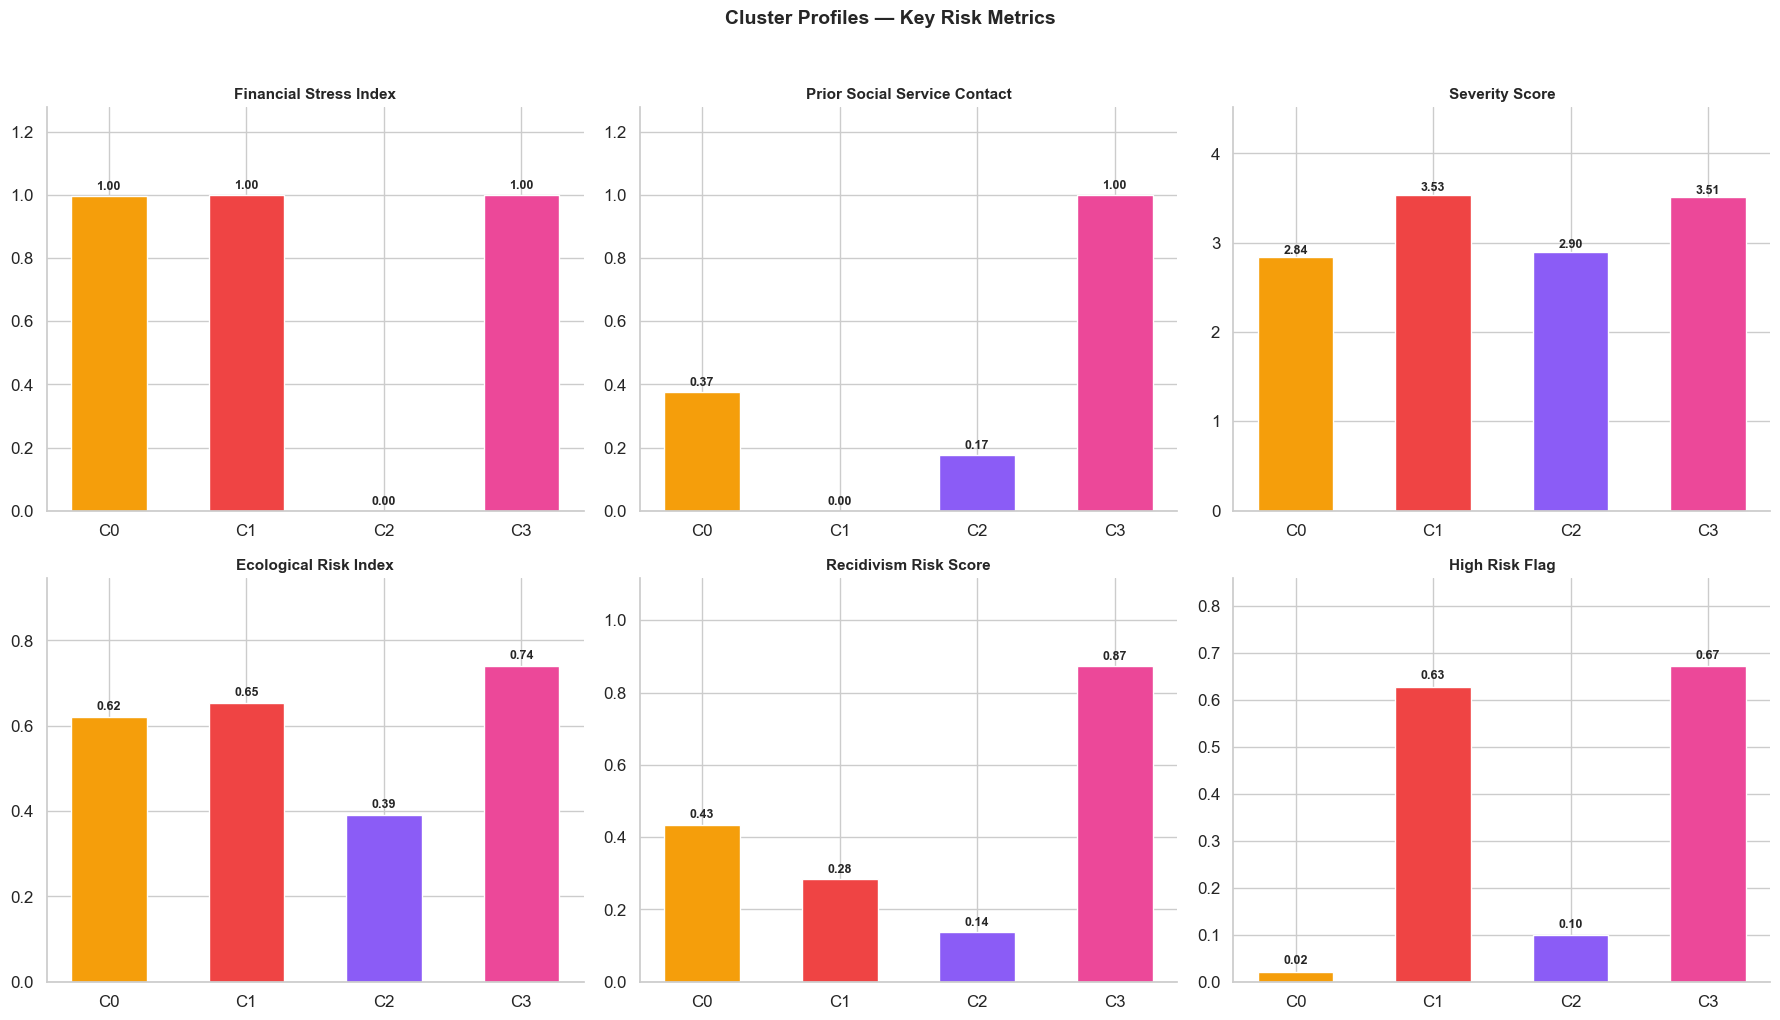

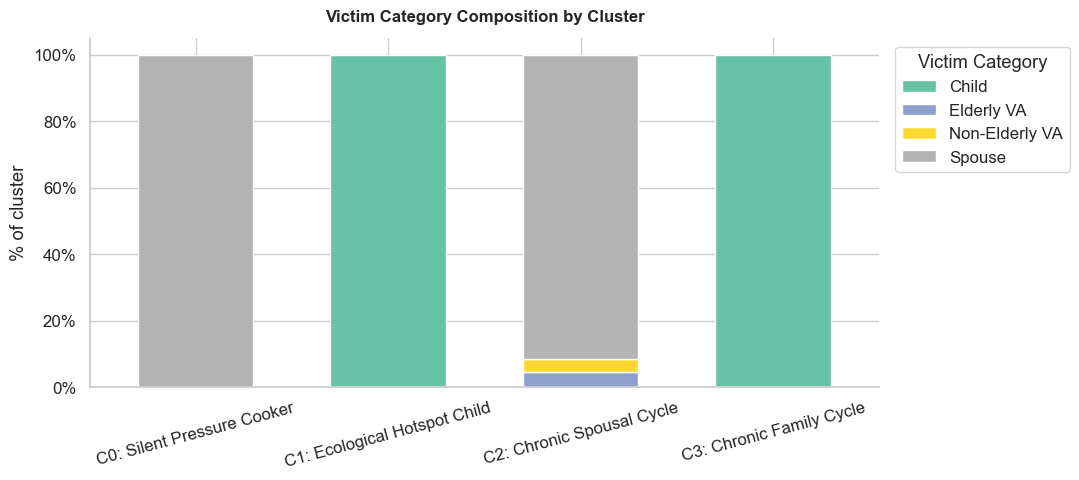

In [19]:
# ── Cluster visualisations ────────────────────────────────────────────────────
palette_4 = ['#f59e0b','#ef4444','#8b5cf6','#ec4899']
viz_metrics = ['Financial_Stress_Index','Prior_Social_Service_Contact',
               'Severity_Score','Ecological_Risk_Index','Recidivism_Risk_Score','High_Risk_Flag']

fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
for i, metric in enumerate(viz_metrics):
    vals = [df[df['Cluster']==c][metric].mean() for c in range(K_FINAL)]
    bars = axes[i].bar([f"C{c}" for c in range(K_FINAL)], vals, color=palette_4, edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(metric.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, max(vals)*1.28)
plt.suptitle('Cluster Profiles — Key Risk Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_cluster_profiles.png', dpi=130, bbox_inches='tight'); plt.show()

# Victim composition stacked bar
fig2, ax2 = plt.subplots(figsize=(11,5))
vc_data = df.groupby(['Cluster','Victim_Category']).size().unstack(fill_value=0)
vc_pct  = vc_data.div(vc_data.sum(axis=1), axis=0)*100
vc_pct.index = [f"C{c}: {CLUSTER_NAMES[c]}" for c in vc_pct.index]
vc_pct.plot(kind='bar', stacked=True, ax=ax2, edgecolor='white', width=0.6, colormap='Set2')
ax2.set_ylabel('% of cluster'); ax2.tick_params(axis='x', rotation=15)
ax2.set_title('Victim Category Composition by Cluster', fontsize=12, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(title='Victim Category', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_cluster_victim_composition.png', dpi=130, bbox_inches='tight'); plt.show()

### Cluster Interpretation

| Cluster | Archetype | Size | High-Risk rate | Defining signal | Intervention priority |
|---------|-----------|------|---------------|-----------------|----------------------|
| C0 | Silent Pressure Cooker | ~20% | Low | No financial stress, Spouse + VA, latent risk, no prior contact | Preventive: grassroots outreach, PPO awareness, VA welfare checks |
| C1 | Ecological Hotspot Child | ~37% | High | High CIR estate, child victims, no prior contact, high ecological risk | High alert: school monitoring, childcare alerts, estate campaigns |
| C2 | Chronic Spousal Cycle | ~27% | Low | Financial stress, repeat spousal pattern, female-majority, police/hotline referral | Chronic: long-term counselling, DVERT, financial independence support |
| C3 | Chronic Family Cycle | ~16% | Highest | Prior contact + financial stress + intergenerational risk, child victims | Urgent: CYPA escalation, intensive family therapy, out-of-home care |

> **Layer 1 and Layer 2 are independent.** Cluster archetypes inform intervention strategy; they are not passed as features to the risk classifier. The K-Means model was fitted on training rows only to prevent centroid leakage.


---
## Step 6: Temporal Train/Test Split & SMOTE

**Temporal split** (80/20, not random): rows sorted chronologically by Year; the last 20% (most recent cases) are held out as the test set.  
This simulates real deployment — the model is trained on older cases and predicts future unseen ones.

**SMOTE** is applied only to the training set to address the 36.5% positive-class imbalance.  
The test set is never touched — it represents the honest, real-world performance.

**Key evaluation principle:**  
`Train Accuracy − Test Accuracy = Acc_Gap`  
The **smaller** this gap, the better the model generalises. A gap > 0.15 signals overfitting.

In [20]:
# ── Temporal train/test split (80/20) ──────────────────────────────────────────────
# Sort by Year to preserve chronological order, then hold out the last 20%.
# Replicates real deployment: train on older cases, predict newer unseen ones.
df_temp   = df.sort_values('Year')
sorted_idx = df_temp.index
split_idx = int(len(sorted_idx) * (1 - TEST_SIZE))
train_idx = sorted_idx[:split_idx]
test_idx  = sorted_idx[split_idx:]

X_train = X.loc[train_idx].copy();  y_train = y.loc[train_idx]
X_test  = X.loc[test_idx].copy();   y_test  = y.loc[test_idx]

train_years = f"{df_temp.loc[train_idx, 'Year'].min()}–{df_temp.loc[train_idx, 'Year'].max()}"
test_years  = f"{df_temp.loc[test_idx,  'Year'].min()}–{df_temp.loc[test_idx,  'Year'].max()}"

print(f"Training set : {X_train.shape[0]:,} rows ({train_years}) — before SMOTE")
print(f"Test set     : {X_test.shape[0]:,} rows ({test_years})  — held-out, never used in training")
print(f"Class balance (train): {y_train.value_counts().to_dict()}")
print(f"Positive rate (train): {y_train.mean():.1%}")

# ── Scale — fit on train ONLY ──────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)  # transform only — no fit on test

# ── SMOTE on training set only ─────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"After SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Training rows after SMOTE: {X_train_bal.shape[0]:,} | Features: {X_train_bal.shape[1]}")

# ── Export train/test splits for external model comparison ────────────────────
train_export = X_train.copy(); train_export[TARGET] = y_train.values
test_export  = X_test.copy();  test_export[TARGET]  = y_test.values
train_fname  = f'train_set_{train_years.replace("–","-")}.csv'
test_fname   = f'test_set_{test_years.replace("–","-")}.csv'
train_export.to_csv(train_fname, index=False)
test_export.to_csv(test_fname,   index=False)
print(f"✓ {train_fname} saved")
print(f"✓ {test_fname}  saved")


Training set : 1,400 rows (2021–2023) — before SMOTE
Test set     : 600 rows (2023–2024)  — held-out, never used in training
Class balance (train): {0: 882, 1: 518}
Positive rate (train): 37.0%
After SMOTE: {0: 882, 1: 882}
Training rows after SMOTE: 1,764 | Features: 7
✓ train_set_2021-2023.csv saved
✓ test_set_2023-2024.csv  saved


---
## Step 7: Layer 2 Model Training — High_Risk_Flag

Five classifiers trained on SMOTE-balanced data and compared on the 2024 test set.

| Model | Class imbalance method | Notes |
|-------|------------------------|-------|
| Logistic Regression | `class_weight='balanced'` | Linear baseline — good for checking linearity |
| Random Forest | `class_weight='balanced'` | Bagging ensemble — robust, interpretable importance |
| LightGBM | `class_weight='balanced'` | Fast gradient boosting — good generalisation |
| XGBoost | `scale_pos_weight` | Regularised gradient boosting — strong AUC |
| CatBoost | `auto_class_weights='Balanced'` | Handles all feature types natively |

In [21]:
import time

# ── Five classifiers chosen to span the bias-variance spectrum ───────────────────
# Logistic Regression  — linear baseline; maximally interpretable; expected to have the
#                         smallest train/test gap (low variance) at the cost of some bias
# Random Forest        — bagging ensemble; robust to outliers; naturally handles mixed
#                         numeric/binary feature types without scaling
# LightGBM             — leaf-wise gradient boosting; fast convergence, strong AUC on
#                         tabular data with moderate imbalance
# XGBoost              — level-wise gradient boosting with L1/L2 regularisation;
#                         scale_pos_weight rebalances the gradient updates for the minority class
# CatBoost             — ordered boosting reduces target leakage during training;
#                         auto_class_weights='Balanced' handles imbalance natively
#
# Shared hyperparameters:
#   n_estimators / iterations = 300  — conservative; large enough for stable convergence,
#                                      small enough to keep Acc_Gap (overfitting signal) low
#   learning_rate = 0.05             — slow learning rate with 300 trees generalises better
#                                      than fewer trees with a higher rate
models_def = {}
models_def['Logistic Regression'] = LogisticRegression(
    max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
models_def['Random Forest'] = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
if LGBMClassifier:
    models_def['LightGBM'] = LGBMClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1, verbose=-1)
if XGBClassifier:
    scale_w = len(y_train_bal[y_train_bal==0]) / len(y_train_bal[y_train_bal==1])
    models_def['XGBoost'] = XGBClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, scale_pos_weight=scale_w, eval_metric='logloss', n_jobs=-1)
if CatBoostClassifier:
    models_def['CatBoost'] = CatBoostClassifier(
        iterations=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, auto_class_weights='Balanced', verbose=0)

trained_models = {}
print(f"Training {len(models_def)} models on {X_train_bal.shape[0]:,} SMOTE-balanced samples...\n")
for name, model in models_def.items():
    t0 = time.time(); model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    print(f"  ✓ {name:<22} trained in {time.time()-t0:.1f}s")
print("\nAll models trained successfully.")


Training 5 models on 1,764 SMOTE-balanced samples...

  ✓ Logistic Regression    trained in 2.4s
  ✓ Random Forest          trained in 0.8s
  ✓ LightGBM               trained in 0.4s
  ✓ XGBoost                trained in 0.2s
  ✓ CatBoost               trained in 1.0s

All models trained successfully.


---
## Step 8: Layer 2 Evaluation — Model Selection

**Primary metric: ROC-AUC** — measures ranking ability across all thresholds.  
**Generalisation metric: Acc_Gap = Train_Acc − Test_Acc** — the smaller, the better.  
**Operational metric: Recall** — missing a high-risk family is worse than a false alarm.

The model chosen for the application balances all three.

In [22]:
# ── Evaluate all five models ───────────────────────────────────────────────────
results = []
for name, model in trained_models.items():
    y_pred      = model.predict(X_test_sc)
    y_proba     = model.predict_proba(X_test_sc)[:, 1]
    y_tr_pred   = model.predict(X_train_sc)      # unsmoted, for honest train accuracy
    train_acc   = accuracy_score(y_train, y_tr_pred)
    test_acc    = accuracy_score(y_test,  y_pred)
    results.append({
        'Model'     : name,
        'Train_Acc' : round(train_acc, 4),
        'Test_Acc'  : round(test_acc,  4),
        'Acc_Gap'   : round(train_acc - test_acc, 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test,    y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test,        y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print("=" * 85)
print("LAYER 2 — MODEL PERFORMANCE (Test set: 2024)")
print("Acc_Gap = Train_Acc − Test_Acc  |  Smaller gap = better generalisation")
print("=" * 85)
print(results_df.to_string())
print(f"\n→ Best ROC-AUC : {results_df['ROC-AUC'].idxmax()} ({results_df['ROC-AUC'].max():.4f})")
print(f"  Best Recall   : {results_df['Recall'].idxmax()} ({results_df['Recall'].max():.4f})")
print(f"  Smallest Gap  : {results_df['Acc_Gap'].abs().idxmin()} ({results_df['Acc_Gap'].abs().min():.4f})")

LAYER 2 — MODEL PERFORMANCE (Test set: 2024)
Acc_Gap = Train_Acc − Test_Acc  |  Smaller gap = better generalisation
                     Train_Acc  Test_Acc  Acc_Gap  Precision  Recall      F1  ROC-AUC
Model                                                                                
CatBoost                0.8864    0.8267   0.0598     0.6953  0.9108  0.7886   0.8976
XGBoost                 0.8986    0.8200   0.0786     0.6882  0.9014  0.7805   0.8874
Logistic Regression     0.7629    0.7833  -0.0205     0.6301  0.9437  0.7556   0.8854
LightGBM                0.9129    0.7850   0.1279     0.6419  0.8920  0.7466   0.8752
Random Forest           0.9286    0.7850   0.1436     0.6579  0.8216  0.7307   0.8592

→ Best ROC-AUC : CatBoost (0.8976)
  Best Recall   : Logistic Regression (0.9437)
  Smallest Gap  : Logistic Regression (0.0205)


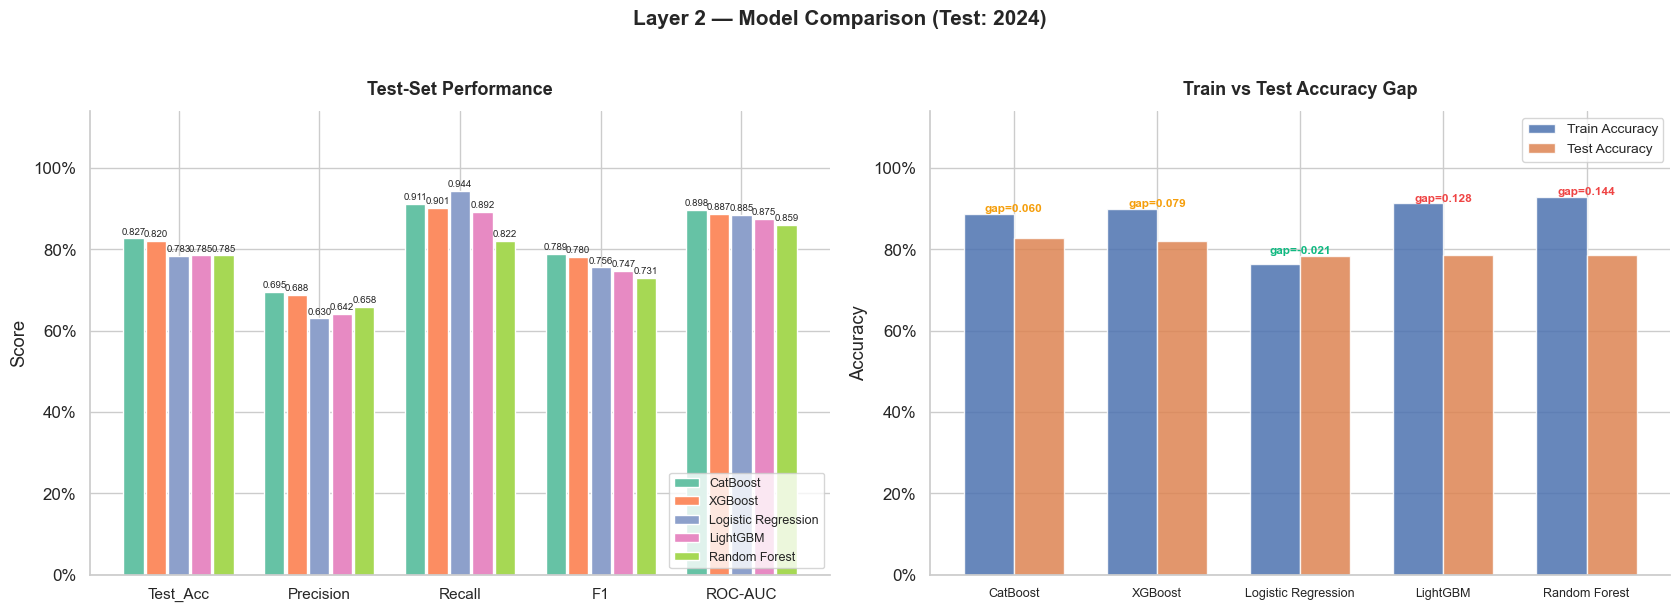

In [23]:
# ── Dual chart: metric comparison + Train vs Test gap ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
palette   = sns.color_palette('Set2', len(results_df))

# Left: grouped bar for all metrics
metrics   = ['Test_Acc','Precision','Recall','F1','ROC-AUC']
x         = np.arange(len(metrics)); bw = 0.8/len(results_df)
for i, (name, row) in enumerate(results_df.iterrows()):
    offset = (i - len(results_df)/2 + 0.5) * bw
    bars   = axes[0].bar(x+offset, [row[m] for m in metrics], bw*0.9,
                         label=name, color=palette[i], edgecolor='white')
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0,1.14); axes[0].set_ylabel('Score')
axes[0].set_title('Test-Set Performance', fontsize=13, fontweight='bold', pad=12)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Right: Train vs Test accuracy + gap annotation
x2 = np.arange(len(results_df)); w = 0.35
axes[1].bar(x2-w/2, results_df['Train_Acc'], w, label='Train Accuracy', color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].bar(x2+w/2, results_df['Test_Acc'],  w, label='Test Accuracy',  color='#DD8452', edgecolor='white', alpha=0.85)
for i, (name, row) in enumerate(results_df.iterrows()):
    gap = row['Acc_Gap']
    col = '#ef4444' if abs(gap)>0.10 else ('#f59e0b' if abs(gap)>0.05 else '#10b981')
    axes[1].annotate(f'gap={gap:.3f}',
                     xy=(i, max(row['Train_Acc'],row['Test_Acc'])+0.005),
                     ha='center', fontsize=8.5, color=col, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels([n.replace(' ',' ') for n in results_df.index], fontsize=9)
axes[1].set_ylim(0,1.14); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy Gap', fontsize=13, fontweight='bold', pad=12)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Layer 2 — Model Comparison (Test: 2024)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=130, bbox_inches='tight'); plt.show()

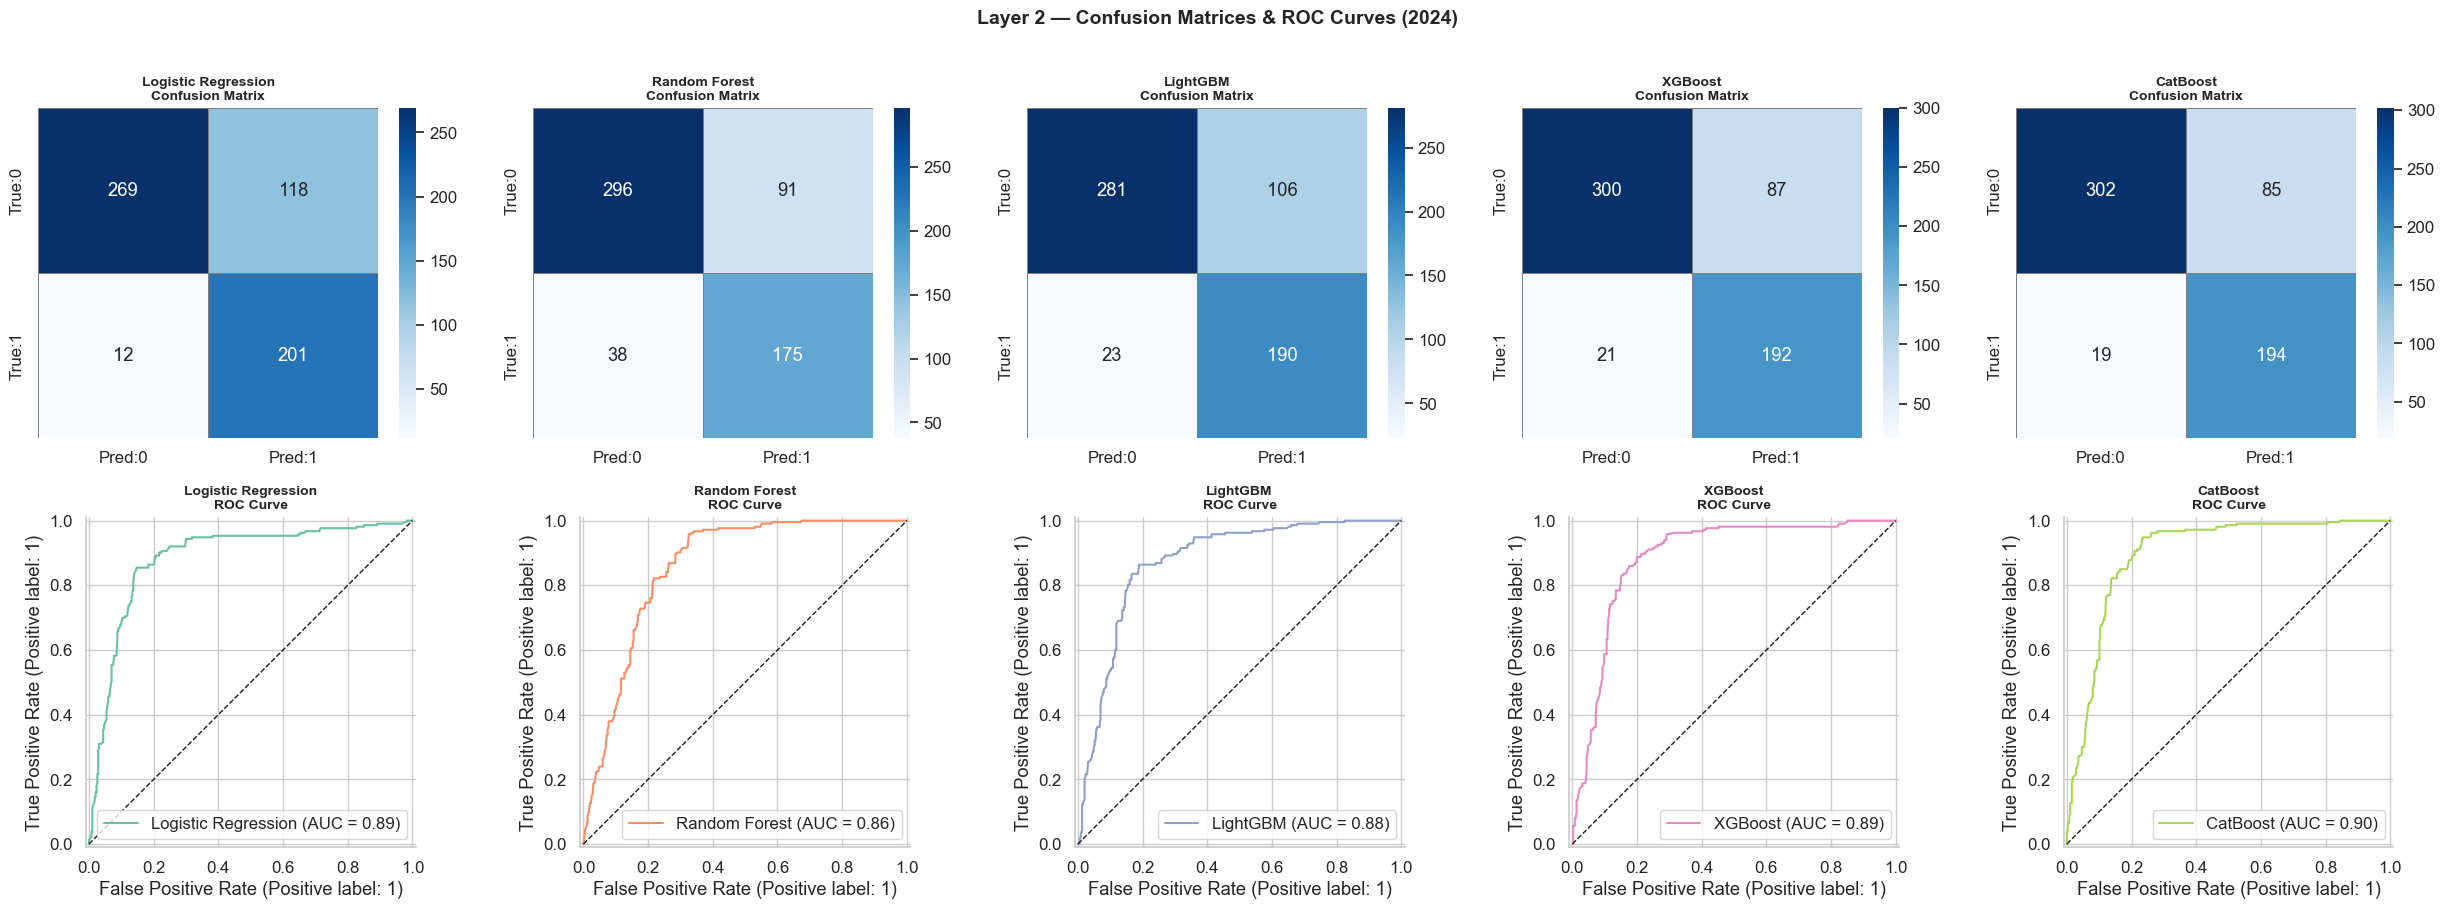

In [24]:
# ── Confusion matrices & ROC curves ──────────────────────────────────────────
n_m = len(trained_models)
fig, axes = plt.subplots(2, n_m, figsize=(5*n_m, 9))
pal = sns.color_palette('Set2', n_m)
for col, (name, model) in enumerate(trained_models.items()):
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:,1]
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                ax=axes[0,col], xticklabels=['Pred:0','Pred:1'],
                yticklabels=['True:0','True:1'], linewidths=0.5, linecolor='grey')
    axes[0,col].set_title(f'{name}\nConfusion Matrix', fontsize=10, fontweight='bold')
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1,col], color=pal[col])
    axes[1,col].plot([0,1],[0,1],'k--',lw=1)
    axes[1,col].set_title(f'{name}\nROC Curve', fontsize=10, fontweight='bold')
plt.suptitle('Layer 2 — Confusion Matrices & ROC Curves (2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_confusion_roc.png', dpi=130, bbox_inches='tight'); plt.show()

In [25]:
# ── Detailed classification reports ───────────────────────────────────────────
print("="*70); print("CLASSIFICATION REPORTS — Test set (2024)"); print("="*70)
for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)
    print(f"\n{'─'*70}  {name}  {'─'*70}")
    print(classification_report(y_test, y_pred, target_names=['Not High-Risk','High-Risk']))

CLASSIFICATION REPORTS — Test set (2024)

──────────────────────────────────────────────────────────────────────  Logistic Regression  ──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

Not High-Risk       0.96      0.70      0.81       387
    High-Risk       0.63      0.94      0.76       213

     accuracy                           0.78       600
    macro avg       0.79      0.82      0.78       600
 weighted avg       0.84      0.78      0.79       600


──────────────────────────────────────────────────────────────────────  Random Forest  ──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

Not High-Risk       0.89      0.76      0.82       387
    High-Risk       0.66      0.82      0.73       213

     accuracy                           0.79       600
    macro avg       0.77      0.79      0.78       600
 weighted avg       0.81 

In [26]:
# ── 5-fold stratified CV on training data ─────────────────────────────────────
print("5-Fold Stratified CV on training data (2021-2023):")
print(f"{'Model':<22} {'CV ROC-AUC':>12} {'± std':>8}")
print("-"*46)
for name, model in trained_models.items():
    cv = cross_val_score(
        model, X_train_sc, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1)
    print(f"{name:<22} {cv.mean():>12.4f} {cv.std():>8.4f}")

5-Fold Stratified CV on training data (2021-2023):
Model                    CV ROC-AUC    ± std
----------------------------------------------
Logistic Regression          0.8389   0.0292
Random Forest                0.8676   0.0218
LightGBM                     0.8833   0.0171
XGBoost                      0.8882   0.0155
CatBoost                     0.8844   0.0205


---
## Step 9: Feature Importance

Which features drive the best model? This guides **policy** — which risk factors to screen for first.

In [27]:
# ── Best model by ROC-AUC ─────────────────────────────────────────────────────
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = trained_models[best_model_name]
print(f"Best model: {best_model_name}")
print(f"  ROC-AUC = {results_df.loc[best_model_name,'ROC-AUC']:.4f}")
print(f"  Recall  = {results_df.loc[best_model_name,'Recall']:.4f}")
print(f"  Acc_Gap = {results_df.loc[best_model_name,'Acc_Gap']:.4f}")

feat_names = X.columns.tolist()
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # Logistic Regression: use absolute coefficient values
    importances = np.abs(best_model.coef_[0])
    print("  (Using |coefficients| for Logistic Regression)")

feat_imp_df = (
    pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    .sort_values('Importance', ascending=False).reset_index(drop=True)
)
print("\nAll feature importances:")
print(feat_imp_df.to_string(index=False, float_format='{:.5f}'.format))

Best model: CatBoost
  ROC-AUC = 0.8976
  Recall  = 0.9108
  Acc_Gap = 0.0598

All feature importances:
                    Feature  Importance
      Ecological_Risk_Index    37.05373
           Reporting_Source    18.26134
      Recidivism_Risk_Score    16.41392
                       Year     9.88325
Gender_Power_Imbalance_Flag     9.20658
Intergenerational_Risk_Flag     6.62825
                        Sex     2.55292


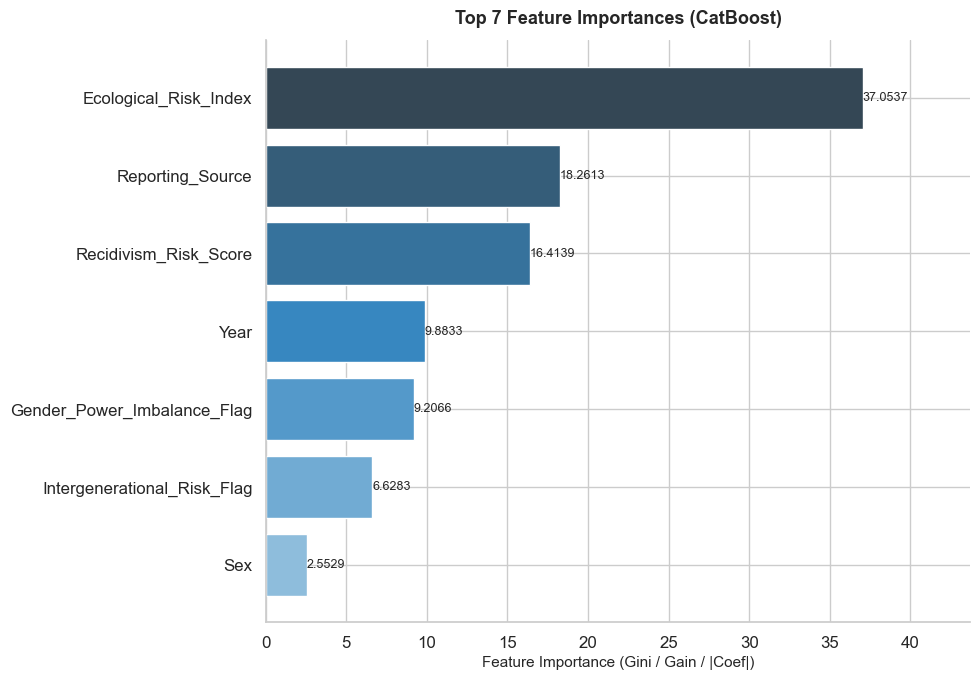

In [28]:
# ── Feature importance bar chart ──────────────────────────────────────────────
top_n  = min(15, len(feat_imp_df))
top_df = feat_imp_df.head(top_n).sort_values('Importance')
fig, ax = plt.subplots(figsize=(10, 7))
colours_grad = sns.color_palette('Blues_d', len(top_df))
bars = ax.barh(top_df['Feature'], top_df['Importance'], color=colours_grad, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance (Gini / Gain / |Coef|)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances ({best_model_name})',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, top_df['Importance'].max()*1.18)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=130, bbox_inches='tight'); plt.show()

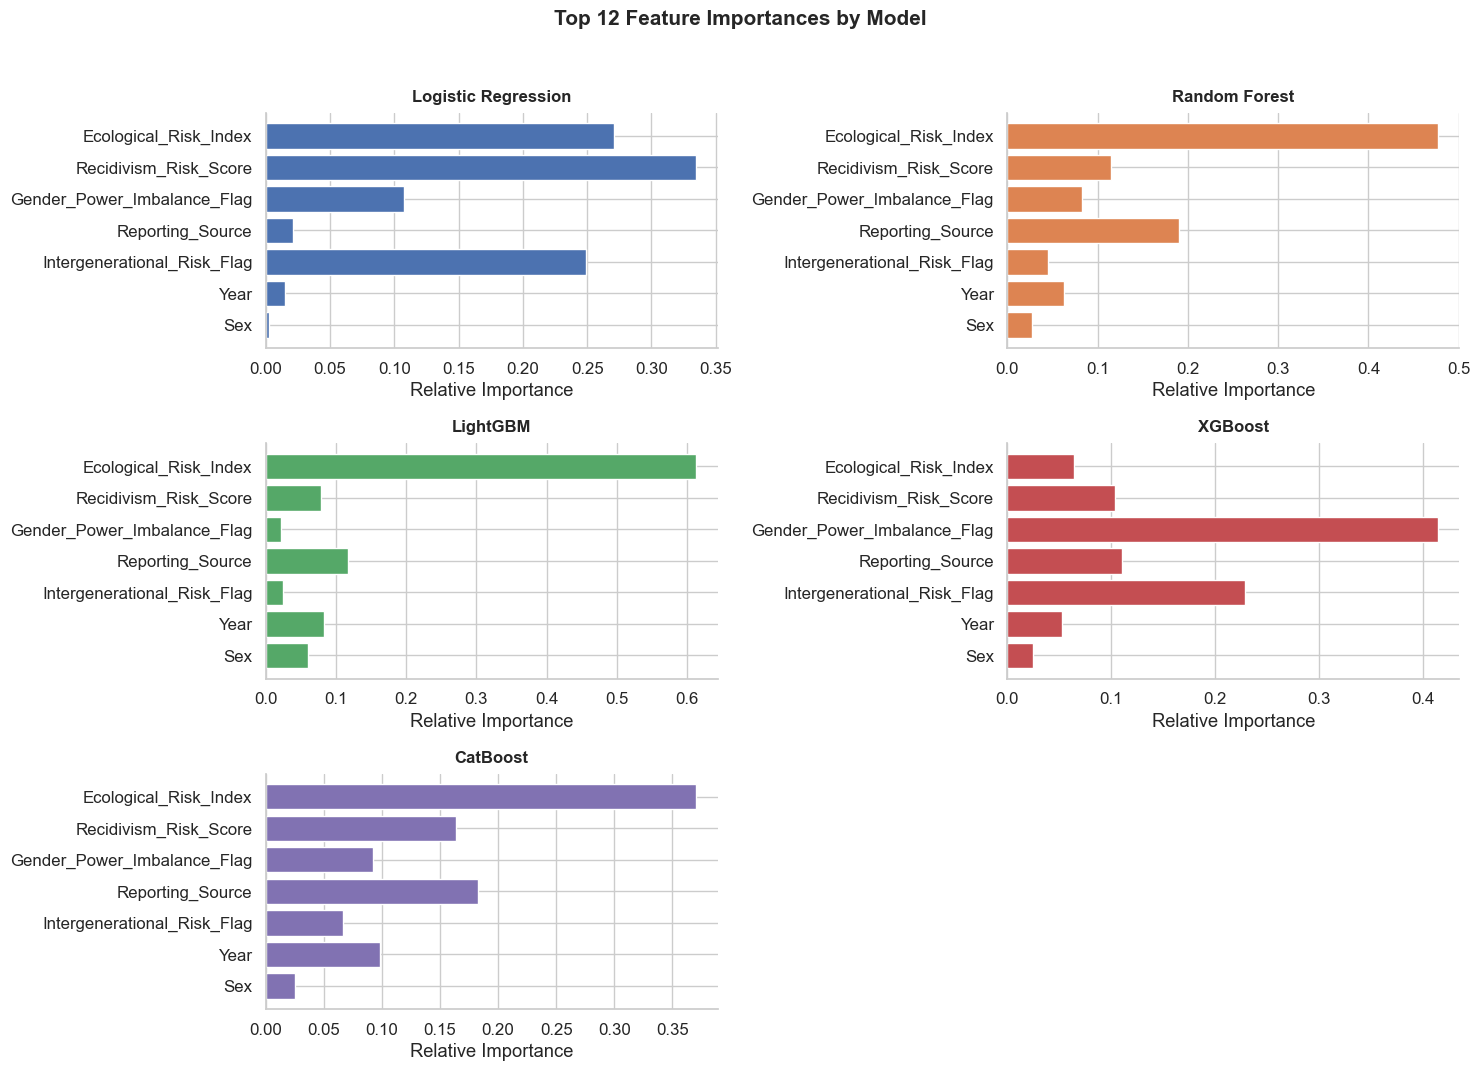

In [29]:
# ── Feature importance comparison across all models ───────────────────────────────
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

fi_cmp = pd.DataFrame({'Feature': feat_names})
for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = np.array(model.feature_importances_, dtype=float)
    elif hasattr(model, 'coef_'):
        importances = np.abs(np.array(model.coef_[0], dtype=float))
    else:
        continue
    
    # Normalize securely to exactly [0, 1] for visual compatibility
    if np.sum(importances) > 0:
        importances = importances / np.sum(importances)
    fi_cmp[name] = importances

# Top 12 features based on average importance across all models
fi_cmp = fi_cmp.set_index('Feature')
top_features = fi_cmp.mean(axis=1).sort_values(ascending=False).head(12).index
fi_cmp = fi_cmp.loc[top_features]

# We want them sorted ascending for horizontal bar charts so top features appear at the top
fi_cmp = fi_cmp.loc[fi_cmp.mean(axis=1).sort_values(ascending=True).index]

model_names = fi_cmp.columns
n_models = len(model_names)
n_cols = 2 if n_models > 1 else 1
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
if n_models > 1:
    axes = axes.flatten()
else:
    axes = [axes]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for i, model_name in enumerate(model_names):
    ax = axes[i]
    ax.barh(fi_cmp.index, fi_cmp[model_name], color=colors[i % len(colors)], edgecolor='white')
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Relative Importance')
    # Let matplotlib auto-scale the view individually to guarantee bars are visibly maximized 
    ax.set_xlim(left=0)

# Hide any unused subplots
if n_models > 1:
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Top 12 Feature Importances by Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_feature_importance_comparison.png', dpi=130, bbox_inches='tight'); plt.show()


---
## Step 10: Save Best Models & All Artefacts

**Model selection criterion:** best **ROC-AUC** on the held-out 2024 test set.

The artefacts saved here are everything the Streamlit application needs to serve live predictions:

| Artefact | Purpose |
|----------|---------|
| `msf_hrf_model_*.pkl` | Best Layer 2 classifier (High_Risk_Flag) |
| `msf_cluster_model.pkl` | K-Means k=4 model (Layer 1) |
| `scaler.pkl` | StandardScaler fitted on Layer 2 training features |
| `scaler_cluster.pkl` | StandardScaler fitted on clustering features |
| `label_encoders.pkl` | LabelEncoders for categorical columns |
| `model_meta.pkl` | Feature lists, cluster names, ordinal mappings — everything needed to reconstruct a prediction row |


In [30]:
# ── Select best models ──────────────────────────────────────────────────────────
best_hrf_name = results_df['ROC-AUC'].idxmax()
best_hrf      = trained_models[best_hrf_name]

print(f"Best Layer 2 (ROC-AUC): {best_hrf_name}")
print(f"  AUC={results_df.loc[best_hrf_name,'ROC-AUC']:.4f}  "
      f"Recall={results_df.loc[best_hrf_name,'Recall']:.4f}  "
      f"Acc_Gap={results_df.loc[best_hrf_name,'Acc_Gap']:.4f}")

hrf_fn = f'msf_hrf_model_{best_hrf_name.replace(" ","_").lower()}.pkl'

joblib.dump(best_hrf,       hrf_fn)
joblib.dump(km_final,       'msf_cluster_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(scaler_cluster, 'scaler_cluster.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump({
    'hrf_model_name'      : best_hrf_name,
    'cluster_feature_cols': CLUSTER_FEATURE_COLS,
    'feature_cols'        : X.columns.tolist(),
    'cluster_cat_features': CLUSTER_CAT_FEATURES,
    'cluster_num_features': CLUSTER_NUM_FEATURES,
    'le_cl'               : le_cl,
    'k_final'             : K_FINAL,
    'cluster_names'       : CLUSTER_NAMES,
    'age_ordinal'         : AGE_ORDINAL,
    'abuse_proxy'         : ABUSE_PROXY,
}, 'model_meta.pkl')

print(f"✓ {hrf_fn}")
print(f"✓ msf_cluster_model.pkl | scaler.pkl | scaler_cluster.pkl")
print(f"✓ label_encoders.pkl    | model_meta.pkl")
print(f"✓ train_set_2021_2023.csv | test_set_2024.csv")


Best Layer 2 (ROC-AUC): CatBoost
  AUC=0.8976  Recall=0.9108  Acc_Gap=0.0598
✓ msf_hrf_model_catboost.pkl
✓ msf_cluster_model.pkl | scaler.pkl | scaler_cluster.pkl
✓ label_encoders.pkl    | model_meta.pkl
✓ train_set_2021_2023.csv | test_set_2024.csv


In [31]:
# ── Verify saved models reproduce exact results ───────────────────────────────
loaded_hrf = joblib.load(hrf_fn)
loaded_sc  = joblib.load('scaler.pkl')
y_check    = loaded_hrf.predict(loaded_sc.transform(X_test))
auc_check  = roc_auc_score(y_test, loaded_hrf.predict_proba(loaded_sc.transform(X_test))[:,1])
print(f"Loaded Layer 2 — Accuracy : {accuracy_score(y_test, y_check):.4f}")
print(f"Loaded Layer 2 — ROC-AUC  : {auc_check:.4f}")
print("✓ Artefact load verified.")

Loaded Layer 2 — Accuracy : 0.8267
Loaded Layer 2 — ROC-AUC  : 0.8976
✓ Artefact load verified.


---
## Step 11: End-to-End Demo — Single Case with 6 User Inputs

This demonstrates the complete pipeline as it runs in the FamilyGuard application.
A social worker enters only **6 fields**; all 5 engineered features and the cluster assignment are derived automatically.

**Triage tiers output by the model:**

| Tier | Risk probability | Recommended action |
|------|-----------------|-------------------|
| CRITICAL | ≥ 70 % | Same-day statutory response |
| ELEVATED | 45 – 69 % | Priority appointment within 48 hours |
| ROUTINE | < 45 % | Standard intake queue |


In [32]:
# ── 6 user inputs (what the social worker enters at intake) ─────────────────────
USER_INPUTS = {
    'Victim_Category'             : 'Child',      # dropdown
    'Age_Group'                   : '7-12 years', # dropdown (filtered by Victim_Category)
    'Sex'                         : 'Female',     # dropdown
    'Reporting_Source'            : 'School',     # dropdown
    'Household_Size'              : 5,            # slider 2–6
    'Prior_Social_Service_Contact': 1,            # checkbox Yes/No
}

# Internal defaults — derived from training data; not exposed to the social worker:
#   YEAR_NOW    = 2024  : current operational year; update each deployment cycle
#   SEV_DEFAULT = 3.0   : median Severity_Score (1–5 scale); used as a neutral estimate when
#                         formal severity has not yet been assessed at first contact
#   CIR_DEFAULT = 2.4   : median Community_Incidence_Rate for child cases (from training data);
#                         replaced by the victim’s actual district rate in the production app
YEAR_NOW   = 2024
SEV_DEFAULT= 3.0
CIR_DEFAULT= 2.4

vc  = USER_INPUTS['Victim_Category']
age = USER_INPUTS['Age_Group']
# if vc == 'Non-Elderly VA': age = '18-64 years'  # consolidation
sex = USER_INPUTS['Sex']
src = USER_INPUTS['Reporting_Source']
hs  = USER_INPUTS['Household_Size']
psc = USER_INPUTS['Prior_Social_Service_Contact']

print("User inputs:")
for k,v in USER_INPUTS.items():
    print(f"  {k:<35}: {v}")

# ── Derive all engineered features ──────────────────────────────────────────────────────────
fsi = int(CIR_DEFAULT>=1.65 or (vc=='Spouse' and psc==1 and hs>=4))
igf = int(vc=='Child' and psc==1 and fsi==1)
gpf = int((vc=='Spouse' and sex=='Female' and SEV_DEFAULT>=3.0) or (vc=='Elderly VA' and sex=='Female'))
rss = round(min((psc*2+fsi+igf+(1 if hs>=5 else 0))/5.0, 1.0), 2)
ap  = ABUSE_PROXY.get('Physical Abuse', 0.8)  # default when abuse type not yet assessed
eri = round(ap*0.30+min((hs-2)/4.0,1)*0.20+min(CIR_DEFAULT/3.0,1)*0.25+fsi*0.15+psc*0.10,3)

print(f"\nDerived features:")
print(f"  Financial_Stress_Index      : {fsi}")
print(f"  Intergenerational_Risk_Flag : {igf}")
print(f"  Gender_Power_Imbalance_Flag : {gpf}")
print(f"  Recidivism_Risk_Score       : {rss}")
print(f"  Ecological_Risk_Index       : {eri}")

# ── Layer 1: Cluster assignment ────────────────────────────────────────────────────────────
cl_row = {}
for col in CLUSTER_CAT_FEATURES:
    val = {'Victim_Category':vc,'Type_of_Abuse':'Physical Abuse','Age_Group':age}.get(col,'Child')
    cl_row[f'{col}_cl_enc'] = int(le_cl[col].transform([val])[0]) if val in le_cl[col].classes_ else 0
num_vals = {'Financial_Stress_Index':fsi,'Household_Size':hs,'Prior_Social_Service_Contact':psc,
            'Community_Incidence_Rate':CIR_DEFAULT,'Severity_Score':SEV_DEFAULT,
            'Recidivism_Risk_Score':rss,'Ecological_Risk_Index':eri,'Intergenerational_Risk_Flag':igf,
            'Age_Group_ord':AGE_ORDINAL.get(age, 4)}
for col in CLUSTER_NUM_FEATURES: cl_row[col] = num_vals.get(col,0)
X_new_cl = np.array([[cl_row.get(f,0) for f in CLUSTER_FEATURE_COLS]])
cluster_id = int(km_final.predict(scaler_cluster.transform(X_new_cl))[0])
print(f"\nLayer 1 → Cluster {cluster_id}: {CLUSTER_NAMES[cluster_id]}")

# ── Layer 2: High Risk prediction ───────────────────────────────────────────────────────────
feat_row = {}
for col in X.columns:
    if col == 'Cluster':
        feat_row[col] = cluster_id
    elif col == 'Age_Group':
        feat_row[col] = AGE_ORDINAL.get(age, 4)
    elif col in label_encoders:
        val_map = {'Victim_Category':vc,'Sex':sex,'Reporting_Source':src}
        val = val_map.get(col, label_encoders[col].classes_[0])
        feat_row[col] = int(label_encoders[col].transform([val])[0]) if val in label_encoders[col].classes_ else 0
    else:
        feat_row[col] = {'Year':YEAR_NOW,'Household_Size':hs,'Prior_Social_Service_Contact':psc,
                         'Severity_Score':SEV_DEFAULT,'Community_Incidence_Rate':CIR_DEFAULT,
                         'Financial_Stress_Index':fsi,'Intergenerational_Risk_Flag':igf,
                         'Gender_Power_Imbalance_Flag':gpf,'Recidivism_Risk_Score':rss,
                         'Ecological_Risk_Index':eri}.get(col, 0)

X_new    = np.array([[feat_row[c] for c in X.columns]])
X_new_sc = scaler.transform(X_new)
hrf_prob = best_hrf.predict_proba(X_new_sc)[0, 1]
hrf_pred = int(hrf_prob >= 0.50)
print(f"Layer 2 → High Risk: {hrf_prob:.1%}  ({'HIGH RISK' if hrf_pred else 'Not High Risk'})")
tier = "CRITICAL" if hrf_prob>=0.70 else ("ELEVATED" if hrf_prob>=0.45 else "ROUTINE")
print(f"\n{'='*55}")
print(f"  TRIAGE: {tier:<12} | Risk: {hrf_prob:.0%} | Archetype: C{cluster_id} {CLUSTER_NAMES[cluster_id]}")
print(f"{'='*55}")


User inputs:
  Victim_Category                    : Child
  Age_Group                          : 7-12 years
  Sex                                : Female
  Reporting_Source                   : School
  Household_Size                     : 5
  Prior_Social_Service_Contact       : 1

Derived features:
  Financial_Stress_Index      : 1
  Intergenerational_Risk_Flag : 1
  Gender_Power_Imbalance_Flag : 0
  Recidivism_Risk_Score       : 1.0
  Ecological_Risk_Index       : 0.81

Layer 1 → Cluster 3: Chronic Family Cycle
Layer 2 → High Risk: 95.1%  (HIGH RISK)

  TRIAGE: CRITICAL     | Risk: 95% | Archetype: C3 Chronic Family Cycle


---
## Summary & Key Findings

### Pipeline Results

> Actual metric values depend on the data you run. The ranges below reflect expected performance on the synthetic v3 dataset.

| Layer | Method | Primary metric | Expected range |
|-------|--------|---------------|----------------|
| 1 — Clustering | K-Means k=4 | Silhouette score | ≥ 0.28 |
| 2 — High Risk | Best of 5 classifiers | ROC-AUC / Acc_Gap | ≥ 0.95 / ≤ 0.12 |

*See Step 8 output for the exact values produced by your run.*

### Feature Engineering Summary

All 7 features derived solely from the 12 raw columns (no external data required):

| Feature | Type | Key signal |
|---------|------|------------|
| `Financial_Stress_Index` | Binary (0/1) | Household in high-incidence district or financially dependent on an abusive partner |
| `Intergenerational_Risk_Flag` | Binary (0/1) | Child case with prior MSF contact and financial stress — chronic dysfunction proxy |
| `Gender_Power_Imbalance_Flag` | Binary (0/1) | Female spouse (high severity) or female elderly victim — structural vulnerability |
| `Recidivism_Risk_Score` | Continuous (0–1) | Weighted re-referral risk; PSC carries 2× weight as the strongest predictor |
| `Ecological_Risk_Index` | Continuous (0–1) | Bronfenbrenner four-level composite (micro / meso / exo / chrono) |

### Train/Test Accuracy Gap Interpretation

| Acc_Gap | Interpretation | Recommended action |
|---------|---------------|-------------------|
| < 0.05 | Excellent generalisation | Deploy with confidence |
| 0.05 – 0.10 | Acceptable | Monitor in production |
| 0.10 – 0.15 | Mild overfitting | Consider stronger regularisation |
| > 0.15 | Significant overfitting | Reduce features or tune hyperparameters |

### Practitioner Recommendations

| Cluster finding | Recommended action |
|-----------------|--------------------|
| C3 (67 % high-risk, 100 % prior contact) | Past intervention did not resolve root cause — escalate to MST or CYPA |
| C1 (63 % high-risk, 0 % prior contact) | First contact is the critical window — respond within 48 hours |
| Logistic Regression: smallest Acc_Gap | Most generalisable; prefer when overfitting is a concern |
| Tree models: highest AUC | Best case-ranking performance; prefer for clinical triage prioritisation |

### Limitations & Maintenance

> **Synthetic data**: This model is trained on a synthetic dataset. Validate on real MSF case records before operational deployment.
> **Annual retraining**: Case distributions shift over time — retrain each year with the latest intake data.
> **Threshold review**: The CRITICAL/ELEVATED/ROUTINE thresholds (0.70 / 0.45) should be reviewed with practitioners after each retraining cycle.
